In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder

# FASE 1 — Comprensión del Dataset

## Carga del dataset

In [3]:
# Carga robusta para Colab: monta Drive, busca el archivo y hace fallback a files.upload()
from google.colab import drive, files
import glob, io, os, pandas as pd

# Montar Google Drive (si no está montado ya)
drive.mount('/content/drive')

# Buscar el CSV en MyDrive (patrón flexible)
matches = glob.glob('/content/drive/MyDrive/**/02_04_crash_severity*.csv', recursive=True)
if matches:
    path = matches[0]
    print('Archivo encontrado en Drive:', path, os.path.exists(path), os.path.getsize(path))
    try:
        df = pd.read_csv(path, low_memory=False, encoding='utf-8')
    except Exception as e:
        print('Error leyendo con utf-8, intentando latin-1:', e)
        df = pd.read_csv(path, low_memory=False, encoding='latin-1')
else:
    print('Archivo no encontrado en Drive. Abriendo diálogo para subir archivo desde tu equipo...')
    uploaded = files.upload()
    fname = next(iter(uploaded))
    df = pd.read_csv(io.BytesIO(uploaded[fname]), low_memory=False, encoding='utf-8')

print('Dataset cargado. Shape:', df.shape)
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo encontrado en Drive: /content/drive/MyDrive/02_04_crash_severity (1).csv True 4341304
Dataset cargado. Shape: (60000, 27)


,Gravedad_Indicador_Tradicional,Dia_Semana_Acc,Localidad,Clase_Acc,Elemento_Choque,Con_Bicicleta,Con_Carga,Con_Embriaguez,Con_Huecos,Con_Menores,...,Con_Sitp,Con_Troncal,Con_Alimentador,Con_Zonal,Con_Provisional,Con_Articulado,Con_Biarticulado,Con_Padron_Dual,Con_Servicio_Especial,Con_Taxi
0,Con Heridos,miércoles,CHAPINERO,Volcamiento,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Con Heridos,jueves,ANTONIO NARIÑO,Atropello,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI,NaN
2,Solo Daños,viernes,USAQUÉN,Choque,Vehículo,NaN,SI,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SI,NaN
3,Con Heridos,jueves,ENGATIVÁ,Choque,Vehículo,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Solo Daños,miércoles,PUENTE ARANDA,Choque,Vehículo,NaN,SI,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Idendificion de dimesiones

In [4]:
columns = df.columns.to_list()

# Filter out columns that start with 'Con_'
filtered_columns = [col for col in columns if not col.startswith('Con_')]
dimensions = filtered_columns

print('Dimensiones identificadas', dimensions)

Dimensiones identificadas ['Gravedad_Indicador_Tradicional', 'Dia_Semana_Acc', 'Localidad', 'Clase_Acc', 'Elemento_Choque']


## Idendificion de variables

In [5]:
columns = df.columns.to_list()

# Filter out columns that start with 'Con_'
filtered_columns = [col for col in columns if col.startswith('Con_')]
variables = filtered_columns

print('Variables identificadas', variables)

Variables identificadas ['Con_Bicicleta', 'Con_Carga', 'Con_Embriaguez', 'Con_Huecos', 'Con_Menores', 'Con_Moto', 'Con_Peaton', 'Con_Persona_Mayor', 'Con_Rutas', 'Con_Tpi', 'Con_Tpp', 'Con_Velocidad', 'Con_Sitp', 'Con_Troncal', 'Con_Alimentador', 'Con_Zonal', 'Con_Provisional', 'Con_Articulado', 'Con_Biarticulado', 'Con_Padron_Dual', 'Con_Servicio_Especial', 'Con_Taxi']


## Detectar valores nulos

In [6]:
null_values = df.isnull().sum()
print("Valores nulos por columna:\n", null_values)

Valores nulos por columna:
 Gravedad_Indicador_Tradicional        0
Dia_Semana_Acc                        0
Localidad                             0
Clase_Acc                             0
Elemento_Choque                    9841
Con_Bicicleta                     55258
Con_Carga                         52037
Con_Embriaguez                    58691
Con_Huecos                        59503
Con_Menores                       56777
Con_Moto                          41911
Con_Peaton                        52775
Con_Persona_Mayor                 50232
Con_Rutas                         59982
Con_Tpi                           48711
Con_Tpp                           45880
Con_Velocidad                     59434
Con_Sitp                          50133
Con_Troncal                       59014
Con_Alimentador                   59132
Con_Zonal                         52483
Con_Provisional                   59319
Con_Articulado                    59540
Con_Biarticulado                  59740
Con_Padron_D

## Inconsistencias

### Porcentaje de nulos o faltantes

In [7]:
print(df.isnull().sum() / len(df) * 100)

Gravedad_Indicador_Tradicional     0.000000
Dia_Semana_Acc                     0.000000
Localidad                          0.000000
Clase_Acc                          0.000000
Elemento_Choque                   16.401667
Con_Bicicleta                     92.096667
Con_Carga                         86.728333
Con_Embriaguez                    97.818333
Con_Huecos                        99.171667
Con_Menores                       94.628333
Con_Moto                          69.851667
Con_Peaton                        87.958333
Con_Persona_Mayor                 83.720000
Con_Rutas                         99.970000
Con_Tpi                           81.185000
Con_Tpp                           76.466667
Con_Velocidad                     99.056667
Con_Sitp                          83.555000
Con_Troncal                       98.356667
Con_Alimentador                   98.553333
Con_Zonal                         87.471667
Con_Provisional                   98.865000
Con_Articulado                  

### Valores fuera de nomalidad

In [8]:
con_cols = [col for col in df.columns if col.startswith('Con_')]

for col in con_cols:
    unique = df[col].unique()

    # Define what is considered 'expected' (NaN or 'SI')
    is_expected = lambda val: (val == 'SI') or pd.isna(val)

    # Find values that are not expected
    other_values = [val for val in unique if not is_expected(val)]

    if other_values:
        # Calculate the percentage of these "other" (unexpected) values
        other_count = df[col].isin(other_values).sum()
        total_count = len(df[col])
        percentage_other = (other_count / total_count) * 100 if total_count > 0 else 0
        print(f"{col}: WARNING: Contains unexpected values {other_values}. Percentage of unexpected values: {percentage_other:.2f}%")
    else:
        # If no unexpected values, it means only NaN and/or 'SI' are present.
        # In this case, show the percentage of 'SI' values.
        si_count = (df[col] == 'SI').sum()
        total_count = len(df[col])
        percentage_si = (si_count / total_count) * 100 if total_count > 0 else 0
        print(f"{col}: Unique values: {list(unique)}. Percentage of 'SI' values: {percentage_si:.2f}%")

Con_Bicicleta: Unique values: [nan, 'SI']. Percentage of 'SI' values: 7.90%
Con_Carga: Unique values: [nan, 'SI']. Percentage of 'SI' values: 13.27%
Con_Embriaguez: Unique values: [nan, 'SI']. Percentage of 'SI' values: 2.18%
Con_Huecos: Unique values: [nan, 'SI']. Percentage of 'SI' values: 0.83%
Con_Menores: Unique values: [nan, 'SI']. Percentage of 'SI' values: 5.37%
Con_Moto: Unique values: [nan, 'SI']. Percentage of 'SI' values: 30.15%
Con_Peaton: Unique values: [nan, 'SI']. Percentage of 'SI' values: 12.04%
Con_Persona_Mayor: Unique values: ['SI', nan]. Percentage of 'SI' values: 16.28%


Con_Rutas: Unique values: [nan, 'SI']. Percentage of 'SI' values: 0.03%
Con_Tpi: Unique values: [nan, 'SI']. Percentage of 'SI' values: 18.82%
Con_Tpp: Unique values: [nan, 'SI']. Percentage of 'SI' values: 23.53%
Con_Velocidad: Unique values: [nan, 'SI']. Percentage of 'SI' values: 0.94%
Con_Sitp: Unique values: [nan, 'SI']. Percentage of 'SI' values: 16.45%
Con_Troncal: Unique values: [nan, 'SI']. Percentage of 'SI' values: 1.64%
Con_Alimentador: Unique values: [nan, 'SI']. Percentage of 'SI' values: 1.45%
Con_Zonal: Unique values: [nan, 'SI']. Percentage of 'SI' values: 12.53%
Con_Provisional: Unique values: [nan, 'SI']. Percentage of 'SI' values: 1.14%
Con_Articulado: Unique values: [nan, 'SI']. Percentage of 'SI' values: 0.77%
Con_Biarticulado: Unique values: [nan, 'SI']. Percentage of 'SI' values: 0.43%
Con_Padron_Dual: Unique values: [nan, 'SI']. Percentage of 'SI' values: 0.45%
Con_Servicio_Especial: Unique values: [nan, 'SI']. Percentage of 'SI' values: 3.81%
Con_Taxi: Unique 

### Inconsistencias en dimensiones

In [9]:
for col in dimensions:
    print(df[col].value_counts(dropna=False), end='\n\n')

Gravedad_Indicador_Tradicional
Solo Daños     34270
Con Heridos    24637
Con Muertos     1093
Name: count, dtype: int64

Dia_Semana_Acc
viernes      9535
martes       9141
sábado       9087
miércoles    8949
jueves       8897
lunes        8200
domingo      6191
Name: count, dtype: int64

Localidad
KENNEDY               7279
ENGATIVÁ              6069
USAQUÉN               5396
SUBA                  5375
FONTIBÓN              4713
PUENTE ARANDA         4356
BOSA                  3305
CHAPINERO             3153
BARRIOS UNIDOS        3040
TEUSAQUILLO           3032
CIUDAD BOLÍVAR        2432
LOS MÁRTIRES          1998
SAN CRISTÓBAL         1859
SANTA FE              1779
RAFAEL URIBE URIBE    1701
TUNJUELITO            1689
USME                  1304
ANTONIO NARIÑO        1226
CANDELARIA             293
SUMAPAZ                  1
Name: count, dtype: int64

Clase_Acc
Choque               50324
Atropello             6790
Caida de ocupante     1655
Volcamiento            928
Otro            

### Registros sin ninguna condicion

In [10]:
non_codition = df.copy()

df_con_numeric = non_codition[con_cols].apply(
    lambda col: col.map(lambda x: 1 if str(x).strip().upper() == 'SI' else 0)
)

df['total_condiciones'] = df_con_numeric.sum(axis=1)
sin_condiciones = df[df['total_condiciones'] == 0]
print(f"Accidentes sin ninguna condición registrada: {len(sin_condiciones)}")

Accidentes sin ninguna condición registrada: 8624


In [11]:
total = len(df)
pct = len(sin_condiciones) / total * 100
print(f"Representan el {pct:.2f}% del dataset ({len(sin_condiciones)} de {total})")

Representan el 14.37% del dataset (8624 de 60000)


### Duplicados exactos

In [12]:
original_cols = [col for col in df.columns if col != 'total_condiciones']

real_duplicate = df.duplicated(subset=original_cols, keep=False)

print(f"Filas duplicadas (columnas originales): {df.duplicated(subset=original_cols).sum()}")
print(f"Filas únicas reales: {len(df) - df.duplicated(subset=original_cols).sum()}")

Filas duplicadas (columnas originales): 44017
Filas únicas reales: 15983


## Crear diccionario de datos

In [13]:
diccionario = pd.DataFrame([
    # Dimensiones
    {'Variable': 'Gravedad_Indicador_Tradicional', 'Tipo': 'Dimensión', 'Descripcion': 'Nivel de gravedad del accidente'},
    {'Variable': 'Dia_Semana_Acc',                 'Tipo': 'Dimensión', 'Descripcion': 'Día de la semana del accidente'},
    {'Variable': 'Localidad',                      'Tipo': 'Dimensión', 'Descripcion': 'Localidad de Bogotá donde ocurrió'},
    {'Variable': 'Clase_Acc',                      'Tipo': 'Dimensión', 'Descripcion': 'Tipo de accidente'},
    {'Variable': 'Elemento_Choque',                'Tipo': 'Dimensión', 'Descripcion': 'Elemento contra el que se chocó'},
    # Variables Con_
    {'Variable': 'Con_Bicicleta',         'Tipo': 'Variable indicadora', 'Descripcion': 'Bicicleta involucrada (SI/NaN)'},
    {'Variable': 'Con_Carga',             'Tipo': 'Variable indicadora', 'Descripcion': 'Vehículo de carga involucrado'},
    {'Variable': 'Con_Embriaguez',        'Tipo': 'Variable indicadora', 'Descripcion': 'Embriaguez como factor'},
    {'Variable': 'Con_Huecos',            'Tipo': 'Variable indicadora', 'Descripcion': 'Mal estado de vía como factor'},
    {'Variable': 'Con_Menores',           'Tipo': 'Variable indicadora', 'Descripcion': 'Menores de edad involucrados'},
    {'Variable': 'Con_Moto',              'Tipo': 'Variable indicadora', 'Descripcion': 'Motocicleta involucrada'},
    {'Variable': 'Con_Peaton',            'Tipo': 'Variable indicadora', 'Descripcion': 'Peatón involucrado'},
    {'Variable': 'Con_Persona_Mayor',     'Tipo': 'Variable indicadora', 'Descripcion': 'Persona mayor involucrada'},
    {'Variable': 'Con_Rutas',             'Tipo': 'Variable indicadora', 'Descripcion': 'Bus de rutas urbanas involucrado'},
    {'Variable': 'Con_Tpi',               'Tipo': 'Variable indicadora', 'Descripcion': 'Vehículo TPI involucrado'},
    {'Variable': 'Con_Tpp',               'Tipo': 'Variable indicadora', 'Descripcion': 'Vehículo TPP involucrado'},
    {'Variable': 'Con_Velocidad',         'Tipo': 'Variable indicadora', 'Descripcion': 'Exceso de velocidad como factor'},
    {'Variable': 'Con_Sitp',              'Tipo': 'Variable indicadora', 'Descripcion': 'Bus SITP involucrado'},
    {'Variable': 'Con_Troncal',           'Tipo': 'Variable indicadora', 'Descripcion': 'Bus Troncal TransMilenio involucrado'},
    {'Variable': 'Con_Alimentador',       'Tipo': 'Variable indicadora', 'Descripcion': 'Bus Alimentador TransMilenio involucrado'},
    {'Variable': 'Con_Zonal',             'Tipo': 'Variable indicadora', 'Descripcion': 'Bus Zonal SITP involucrado'},
    {'Variable': 'Con_Provisional',       'Tipo': 'Variable indicadora', 'Descripcion': 'Bus Provisional SITP involucrado'},
    {'Variable': 'Con_Articulado',        'Tipo': 'Variable indicadora', 'Descripcion': 'Bus Articulado TransMilenio involucrado'},
    {'Variable': 'Con_Biarticulado',      'Tipo': 'Variable indicadora', 'Descripcion': 'Bus Biarticulado TransMilenio involucrado'},
    {'Variable': 'Con_Padron_Dual',       'Tipo': 'Variable indicadora', 'Descripcion': 'Bus Padrón Dual SITP involucrado'},
    {'Variable': 'Con_Servicio_Especial', 'Tipo': 'Variable indicadora', 'Descripcion': 'Vehículo Servicio Especial involucrado'},
    {'Variable': 'Con_Taxi',              'Tipo': 'Variable indicadora', 'Descripcion': 'Taxi involucrado'},
])

display(diccionario)

,Variable,Tipo,Descripcion
0,Gravedad_Indicador_Tradicional,Dimensión,Nivel de gravedad del accidente
1,Dia_Semana_Acc,Dimensión,Día de la semana del accidente
2,Localidad,Dimensión,Localidad de Bogotá donde ocurrió
3,Clase_Acc,Dimensión,Tipo de accidente
4,Elemento_Choque,Dimensión,Elemento contra el que se chocó
5,Con_Bicicleta,Variable indicadora,Bicicleta involucrada (SI/NaN)
6,Con_Carga,Variable indicadora,Vehículo de carga involucrado
7,Con_Embriaguez,Variable indicadora,Embriaguez como factor
8,Con_Huecos,Variable indicadora,Mal estado de vía como factor
9,Con_Menores,Variable indicadora,Menores de edad involucrados


In [14]:
clasificacion = pd.DataFrame([
    {'Variable': 'Gravedad_Indicador_Tradicional', 'Clasificacion': 'Cualitativa ordinal',  'Razon': 'Tiene jerarquía: solo daños < heridos < muertos'},
    {'Variable': 'Dia_Semana_Acc',                 'Clasificacion': 'Cualitativa ordinal',  'Razon': 'Tiene orden: lunes a domingo'},

    {'Variable': 'Localidad',       'Clasificacion': 'Cualitativa nominal', 'Razon': 'Categorías sin orden entre sí'},
    {'Variable': 'Clase_Acc',       'Clasificacion': 'Cualitativa nominal', 'Razon': 'Tipos de accidente sin jerarquía'},
    {'Variable': 'Elemento_Choque', 'Clasificacion': 'Cualitativa nominal', 'Razon': 'Elementos sin orden entre sí'},

    {'Variable': 'Con_* (cada una)', 'Clasificacion': 'Cuantitativa discreta', 'Razon': 'Binaria 0/1, al agregarlas produce conteos numéricos'},
])

display(clasificacion)

,Variable,Clasificacion,Razon
0,Gravedad_Indicador_Tradicional,Cualitativa ordinal,Tiene jerarquía: solo daños < heridos < muertos
1,Dia_Semana_Acc,Cualitativa ordinal,Tiene orden: lunes a domingo
2,Localidad,Cualitativa nominal,Categorías sin orden entre sí
3,Clase_Acc,Cualitativa nominal,Tipos de accidente sin jerarquía
4,Elemento_Choque,Cualitativa nominal,Elementos sin orden entre sí
5,Con_* (cada una),Cuantitativa discreta,"Binaria 0/1, al agregarlas produce conteos num..."


## Preguntas críticas

### ¿Qué tan confiable parece el dataset?

El dataset presenta señales mixtas de confiabilidad. Por un lado, las dimensiones
principales (Gravedad, Localidad, Clase_Acc, Dia_Semana_Acc) no tienen valores nulos,
lo que sugiere un registro sistemático del evento base.

### ¿Existen variables que puedan inducir sesgos?

Sí. Varias variables pueden introducir sesgos de análisis:

- **Sesgo de subregistro**: variables como Con_Embriaguez (2.18% de SI) o Con_Velocidad
  (0.94%) probablemente no reflejan la realidad, ya que dependen de que el agente de
  tránsito registre activamente el factor. La ausencia de valor no significa ausencia
  del factor.
- **Sesgo geográfico**: la variable Localidad puede sobre-representar zonas con mayor
  presencia policial o de cámaras, no necesariamente las más peligrosas.
- **Sesgo de tipo de vehículo**: Con_Moto tiene el mayor porcentaje de SI (30.15%),
  lo que puede reflejar mayor exposición o mayor rigor en su registro frente a otros
  vehículos.

### ¿La ausencia de datos puede afectar las conclusiones?

Sí, de forma significativa. El patrón de nulos en las columnas Con_* no es aleatorio
(MNAR - Missing Not At Random): un valor NaN no significa que la condición estaba
ausente, sino que probablemente no fue registrada. Esto implica que:

- Cualquier análisis de frecuencia de factores estará subestimado.
- Comparaciones entre localidades o días de semana pueden ser engañosas si el nivel
  de registro varía por zona o turno.
- Los 44.017 duplicados, si no se eliminan, inflarán artificialmente las frecuencias
  de ciertos patrones de accidente.

### ¿Qué implicaciones éticas tendría una mala interpretación de estos datos?

Una mala interpretación podría tener consecuencias reales en política pública:

- **Asignación incorrecta de recursos**: concluir que la embriaguez es un factor menor
  (2.18%) cuando en realidad está subregistrado podría llevar a reducir campañas de
  control de alcoholemia.
- **Estigmatización de actores viales**: un análisis superficial podría culpar
  desproporcionadamente a motociclistas o peatones sin considerar el sesgo de registro.
- **Falsa sensación de seguridad**: zonas con pocos registros podrían parecer seguras
  cuando en realidad tienen menor cobertura de reporte.
- **Decisiones de infraestructura mal dirigidas**: Con_Huecos casi vacío no significa
  que el estado de las vías no sea un problema, sino que rara vez se documenta como causa.

# FASE 2 — Limpieza y Transformación de Datos

## Tratamiento de nulos

In [15]:
con_cols = [col for col in df.columns if col.startswith('Con_')]
dim_cols = [col for col in df.columns if not col.startswith('Con_')]

df_clean = df.copy()
df_clean[con_cols] = df_clean[con_cols].apply(
    lambda col: col.map(lambda x: 1 if str(x).strip().upper() == 'SI' else 0)
)
df_clean['Elemento_Choque'] = df_clean['Elemento_Choque'].fillna('Desconocido')

print("Nulos restantes:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])
print("\nShape después del tratamiento de nulos:", df_clean.shape)

Nulos restantes:
Series([], dtype: int64)

Shape después del tratamiento de nulos: (60000, 28)


## Eliminación de duplicados

In [16]:
df_clean = df_clean.copy()
print("Se conservan todos los registros. Duplicados no eliminados.")
print(f"Shape: {df_clean.shape}")

Se conservan todos los registros. Duplicados no eliminados.
Shape: (60000, 28)


### Desicision sobre eliminacion de duplicados

Llegamos a la conclusion de no eliminar los duplicados ya que tras analizar la cantidad de duplicados encontramos 44017, los cuales represetan alrededor de 73% de la data y teniendo en cuenta que el dataset no incluye un identificador único de evento, no es posible confirmar que filas idénticas
sean el mismo registro cargado dos veces.

## Estandarización de variables categóricas

In [17]:
df_clean = df_clean.copy()

df_clean['Dia_Semana_Acc'] = df_clean['Dia_Semana_Acc'].str.strip().str.capitalize()
df_clean['Elemento_Choque'] = df_clean['Elemento_Choque'].fillna('Desconocido')

- **Dia_Semana_Acc**: Se aplicó
  `capitalize()` para consistencia con el resto de variables de texto.
- **Elemento_Choque**: los 9.841 valores NaN lo cual correponde a un 16.4% se establece como
  `'Desconocido'`, ya que las demás dimensiones
  del accidente siguen siendo válidas.

## Conversión de variables

In [18]:
df_clean['Localidad'] = df_clean['Localidad'].astype('category')
df_clean['Clase_Acc'] = df_clean['Clase_Acc'].astype('category')
df_clean['Elemento_Choque'] = df_clean['Elemento_Choque'].astype('category')

con_cols = [col for col in df_clean.columns if col.startswith('Con_')]
df_clean[con_cols] = df_clean[con_cols].astype('int8')

In [19]:
# Días en Title Case, igual que están en el dataset
dias_orden = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

df_encoded = df_clean.copy()

df_encoded['Dia_Semana_Acc'] = pd.Categorical(
    df_encoded['Dia_Semana_Acc'],
    categories=dias_orden,
    ordered=True
)

gravedad_orden = ['Solo Daños', 'Con Heridos', 'Con Muertos']
df_encoded['Gravedad_Indicador_Tradicional'] = pd.Categorical(
    df_encoded['Gravedad_Indicador_Tradicional'],
    categories=gravedad_orden,
    ordered=True
)

df_encoded['Gravedad_cod'] = df_encoded['Gravedad_Indicador_Tradicional'].cat.codes
df_encoded['Dia_Semana_cod'] = df_encoded['Dia_Semana_Acc'].cat.codes

for col in ['Localidad', 'Clase_Acc', 'Elemento_Choque']:
    df_encoded[f'{col}_cod'], _ = pd.factorize(df_encoded[col])

cols_cod = [c for c in df_encoded.columns if c.endswith('_cod')]
print(df_encoded[cols_cod].head(10))
print("\nValores únicos por columna codificada:")
for col in cols_cod:
    print(f"  {col}: {sorted(df_encoded[col].unique())}")

   Gravedad_cod  Dia_Semana_cod  Localidad_cod  Clase_Acc_cod  \
0             1               2              0              0   
1             1               3              1              1   
2             0               4              2              2   
3             1               3              3              2   
4             0               2              4              2   
5             1               2              2              2   
6             0               1              5              2   
7             0               1              6              2   
8             0               2              7              2   
9             0               5              8              2   

   Elemento_Choque_cod  
0                    0  
1                    0  
2                    1  
3                    1  
4                    1  
5                    2  
6                    1  
7                    2  
8                    1  
9                    1  

Valores 

## Creación de variables derivadas

In [20]:
con_cols = [col for col in df_encoded.columns if col.startswith('Con_')]

df_encoded['total_condiciones'] = df_encoded[con_cols].sum(axis=1)

df_encoded['es_grave'] = (df_encoded['Gravedad_Indicador_Tradicional'] >= 'Con Heridos').astype(int)

tp_cols = ['Con_Sitp', 'Con_Troncal', 'Con_Alimentador', 'Con_Zonal',
           'Con_Provisional', 'Con_Articulado', 'Con_Biarticulado',
           'Con_Padron_Dual', 'Con_Rutas', 'Con_Tpi', 'Con_Tpp']
df_encoded['involucra_tp'] = (df_encoded[tp_cols].sum(axis=1) > 0).astype(int)

df_encoded['usuario_vulnerable'] = (
    (df_encoded['Con_Peaton'] == 1) |
    (df_encoded['Con_Bicicleta'] == 1) |
    (df_encoded['Con_Menores'] == 1) |
    (df_encoded['Con_Persona_Mayor'] == 1)
).astype(int)

print(df_encoded[['total_condiciones', 'es_grave', 'involucra_tp', 'usuario_vulnerable']].describe())
print("\nDistribución es_grave:")
print(df_encoded['es_grave'].value_counts())
print("\nDistribución involucra_tp:")
print(df_encoded['involucra_tp'].value_counts())
print("\nDistribución usuario_vulnerable:")
print(df_encoded['usuario_vulnerable'].value_counts())

       total_condiciones      es_grave  involucra_tp  usuario_vulnerable
count       60000.000000  60000.000000  60000.000000        60000.000000
mean            1.885567      0.428833      0.399733            0.332383
std             1.347121      0.494914      0.489848            0.471071
min             0.000000      0.000000      0.000000            0.000000
25%             1.000000      0.000000      0.000000            0.000000
50%             2.000000      0.000000      0.000000            0.000000
75%             3.000000      1.000000      1.000000            1.000000
max             8.000000      1.000000      1.000000            1.000000

Distribución es_grave:
es_grave
0    34270
1    25730
Name: count, dtype: int64

Distribución involucra_tp:
involucra_tp
0    36016
1    23984
Name: count, dtype: int64

Distribución usuario_vulnerable:
usuario_vulnerable
0    40057
1    19943
Name: count, dtype: int64


# FASE 3 — Estadística Descriptiva

## Medidas de tendencia central

In [21]:
con_cols = [col for col in df_encoded.columns if col.startswith('Con_')]
vars_numericas = con_cols + ['total_condiciones', 'es_grave', 'involucra_tp', 'usuario_vulnerable']

tendencia = df_encoded[vars_numericas].agg(['mean', 'median'])
print(tendencia.T.round(4))

                         mean  median
Con_Bicicleta          0.0790     0.0
Con_Carga              0.1327     0.0
Con_Embriaguez         0.0218     0.0
Con_Huecos             0.0083     0.0
Con_Menores            0.0537     0.0
Con_Moto               0.3015     0.0
Con_Peaton             0.1204     0.0
Con_Persona_Mayor      0.1628     0.0
Con_Rutas              0.0003     0.0
Con_Tpi                0.1882     0.0
Con_Tpp                0.2353     0.0
Con_Velocidad          0.0094     0.0
Con_Sitp               0.1645     0.0
Con_Troncal            0.0164     0.0
Con_Alimentador        0.0145     0.0
Con_Zonal              0.1253     0.0
Con_Provisional        0.0114     0.0
Con_Articulado         0.0077     0.0
Con_Biarticulado       0.0043     0.0
Con_Padron_Dual        0.0045     0.0
Con_Servicio_Especial  0.0381     0.0
Con_Taxi               0.1854     0.0
total_condiciones      1.8856     2.0
es_grave               0.4288     0.0
involucra_tp           0.3997     0.0
usuario_vuln

## Medidas de dispersión

In [22]:
dispersion = df_encoded[vars_numericas].agg(['std', 'min', 'max', 'var'])
print(dispersion.T.round(4))

                          std  min  max     var
Con_Bicicleta          0.2698  0.0  1.0  0.0728
Con_Carga              0.3393  0.0  1.0  0.1151
Con_Embriaguez         0.1461  0.0  1.0  0.0213
Con_Huecos             0.0906  0.0  1.0  0.0082
Con_Menores            0.2255  0.0  1.0  0.0508
Con_Moto               0.4589  0.0  1.0  0.2106
Con_Peaton             0.3255  0.0  1.0  0.1059
Con_Persona_Mayor      0.3692  0.0  1.0  0.1363
Con_Rutas              0.0173  0.0  1.0  0.0003
Con_Tpi                0.3908  0.0  1.0  0.1528
Con_Tpp                0.4242  0.0  1.0  0.1800
Con_Velocidad          0.0967  0.0  1.0  0.0093
Con_Sitp               0.3707  0.0  1.0  0.1374
Con_Troncal            0.1271  0.0  1.0  0.0162
Con_Alimentador        0.1194  0.0  1.0  0.0143
Con_Zonal              0.3310  0.0  1.0  0.1096
Con_Provisional        0.1059  0.0  1.0  0.0112
Con_Articulado         0.0872  0.0  1.0  0.0076
Con_Biarticulado       0.0657  0.0  1.0  0.0043
Con_Padron_Dual        0.0672  0.0  1.0 

## Distribuciones de frecuencia

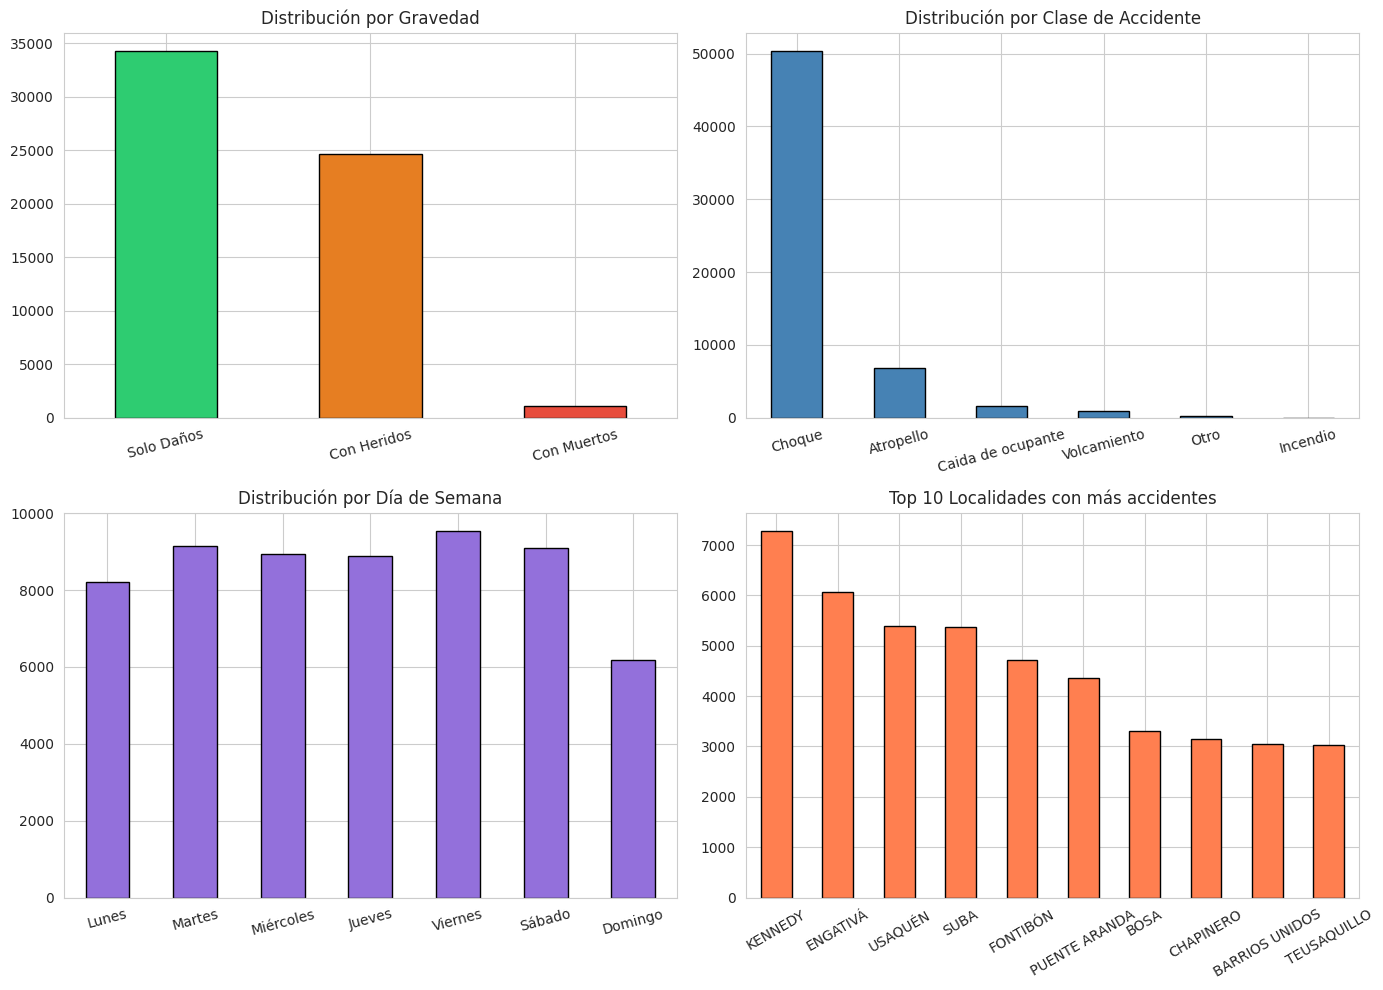

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df_encoded['Gravedad_Indicador_Tradicional'].value_counts().plot(
    kind='bar', ax=axes[0,0], color=['#2ecc71','#e67e22','#e74c3c'], edgecolor='black'
)
axes[0,0].set_title('Distribución por Gravedad')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=15)

df_encoded['Clase_Acc'].value_counts().plot(
    kind='bar', ax=axes[0,1], color='steelblue', edgecolor='black'
)
axes[0,1].set_title('Distribución por Clase de Accidente')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=15)

dia_order = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
df_encoded['Dia_Semana_Acc'].value_counts().reindex(dia_order).plot(
    kind='bar', ax=axes[1,0], color='mediumpurple', edgecolor='black'
)
axes[1,0].set_title('Distribución por Día de Semana')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=15)

df_encoded['Localidad'].value_counts().head(10).plot(
    kind='bar', ax=axes[1,1], color='coral', edgecolor='black'
)
axes[1,1].set_title('Top 10 Localidades con más accidentes')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Histogramas

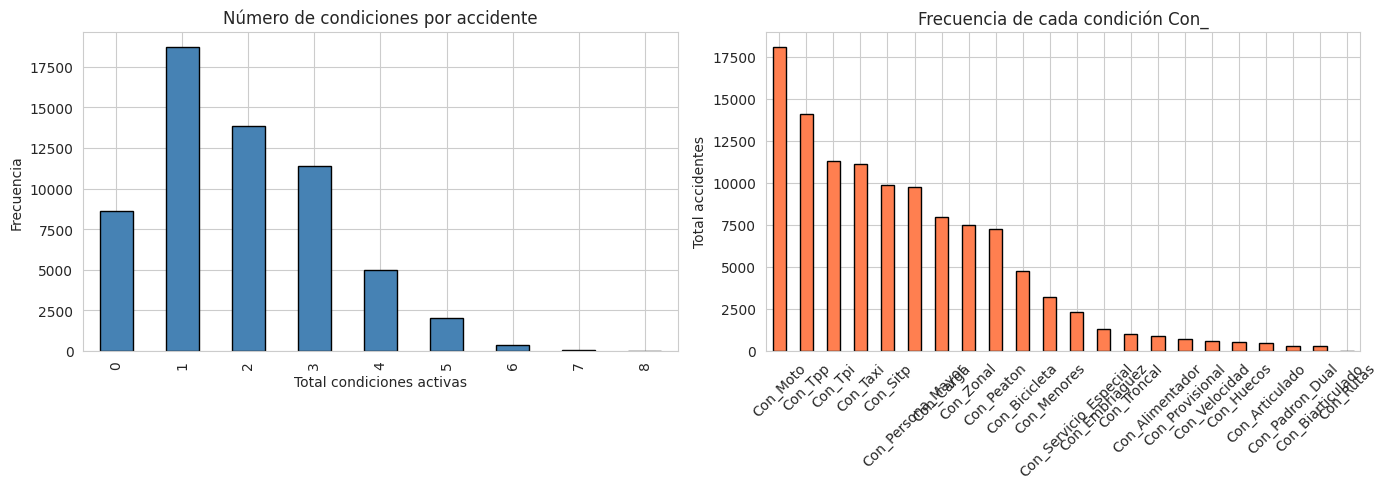

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_encoded['total_condiciones'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Número de condiciones por accidente')
axes[0].set_xlabel('Total condiciones activas')
axes[0].set_ylabel('Frecuencia')

frecuencias_con = df_encoded[con_cols].sum().sort_values(ascending=False)
frecuencias_con.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Frecuencia de cada condición Con_')
axes[1].set_xlabel('')
axes[1].set_ylabel('Total accidentes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Boxplots

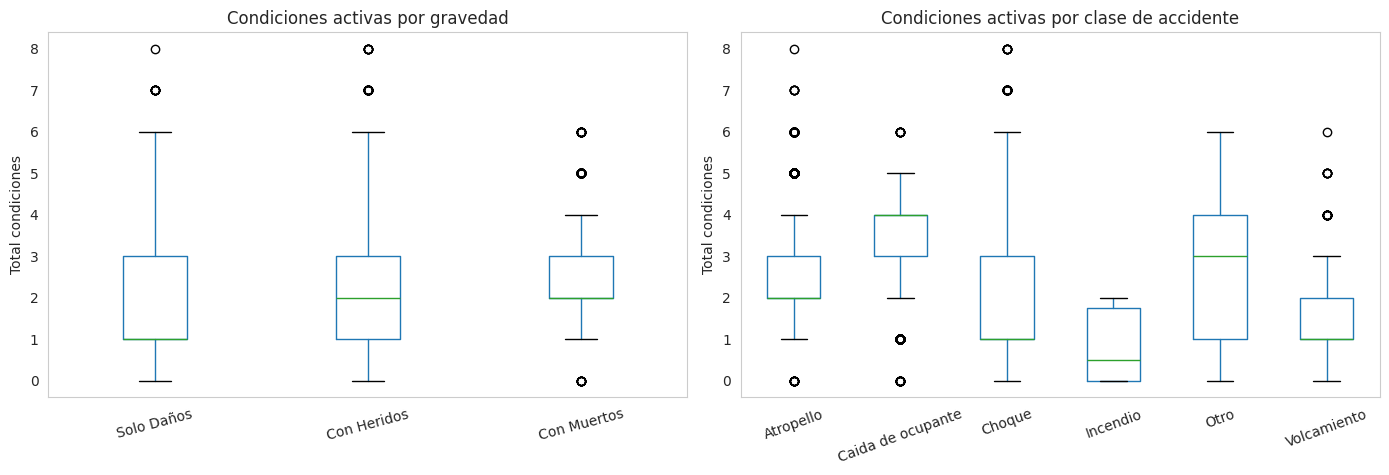

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total condiciones por gravedad
df_encoded.boxplot(column='total_condiciones', by='Gravedad_Indicador_Tradicional',
                   ax=axes[0], grid=False)
axes[0].set_title('Condiciones activas por gravedad')
axes[0].set_xlabel('')
axes[0].set_ylabel('Total condiciones')
plt.sca(axes[0])
plt.xticks(rotation=15)

# Total condiciones por clase de accidente
df_encoded.boxplot(column='total_condiciones', by='Clase_Acc',
                   ax=axes[1], grid=False)
axes[1].set_title('Condiciones activas por clase de accidente')
axes[1].set_xlabel('')
axes[1].set_ylabel('Total condiciones')
plt.sca(axes[1])
plt.xticks(rotation=20)

plt.suptitle('')
plt.tight_layout()
plt.show()

## Tablas dinámicas

### Accidentes por localidad y gravedad

In [26]:
pivot1 = pd.pivot_table(
    df_encoded,
    index='Localidad',
    columns='Gravedad_Indicador_Tradicional',
    values='es_grave',
    aggfunc='count',
    fill_value=0
)
pivot1['Total'] = pivot1.sum(axis=1)
print("Accidentes por Localidad y Gravedad:")
print(pivot1.sort_values('Total', ascending=False).head(10))

Accidentes por Localidad y Gravedad:
Gravedad_Indicador_Tradicional  Solo Daños  Con Heridos  Con Muertos  Total
Localidad                                                                  
KENNEDY                               3634         3474          171   7279
ENGATIVÁ                              3668         2304           97   6069
USAQUÉN                               3969         1375           52   5396
SUBA                                  3118         2178           79   5375
FONTIBÓN                              3097         1534           82   4713
PUENTE ARANDA                         2431         1852           73   4356
BOSA                                  1505         1717           83   3305
CHAPINERO                             2219          902           32   3153
BARRIOS UNIDOS                        2007         1001           32   3040
TEUSAQUILLO                           1951         1055           26   3032


/tmp/ipykernel_28765/3439983749.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot1 = pd.pivot_table(


### Tasa de accidentes graves por día

In [27]:
dia_order = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']
pivot2 = df_encoded.groupby('Dia_Semana_Acc')['es_grave'].agg(['sum','count'])
pivot2['tasa_graves'] = (pivot2['sum'] / pivot2['count'] * 100).round(2)
pivot2.columns = ['Graves', 'Total', 'Tasa (%)']
print("\nTasa de accidentes graves por día de semana:")
print(pivot2.reindex(dia_order))


Tasa de accidentes graves por día de semana:
                Graves  Total  Tasa (%)
Dia_Semana_Acc                         
Lunes             3458   8200     42.17
Martes            3872   9141     42.36
Miércoles         3813   8949     42.61
Jueves            3809   8897     42.81
Viernes           4026   9535     42.22
Sábado            3861   9087     42.49
Domingo           2891   6191     46.70


/tmp/ipykernel_28765/216561846.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot2 = df_encoded.groupby('Dia_Semana_Acc')['es_grave'].agg(['sum','count'])


### Condiciones más frecuentes por clase de accidente

In [28]:
pivot3 = pd.pivot_table(
    df_encoded,
    index='Clase_Acc',
    values=con_cols,
    aggfunc='sum'
)
print("\nCondiciones por clase de accidente:")
print(pivot3.T.sort_values('Choque', ascending=False))


Condiciones por clase de accidente:
Clase_Acc              Atropello  Caida de ocupante  Choque  Incendio  Otro  \
Con_Moto                    2984                 13   14458         1    22   
Con_Tpp                      850               1577   11461         0   202   
Con_Tpi                      563                 19   10665         2     8   
Con_Taxi                     554                 13   10520         2     5   
Con_Carga                    222                  9    7643         0    29   
Con_Sitp                     669               1370    7629         0   179   
Con_Persona_Mayor           1976                614    7086         0    41   
Con_Zonal                    337                977    6115         0    76   
Con_Bicicleta                195                  2    4452         0     9   
Con_Servicio_Especial         80                 10    2188         0     4   
Con_Menores                 1159                203    1761         0    52   
Con_Embriaguez 

/tmp/ipykernel_28765/1277214613.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot3 = pd.pivot_table(


### Correlaciones

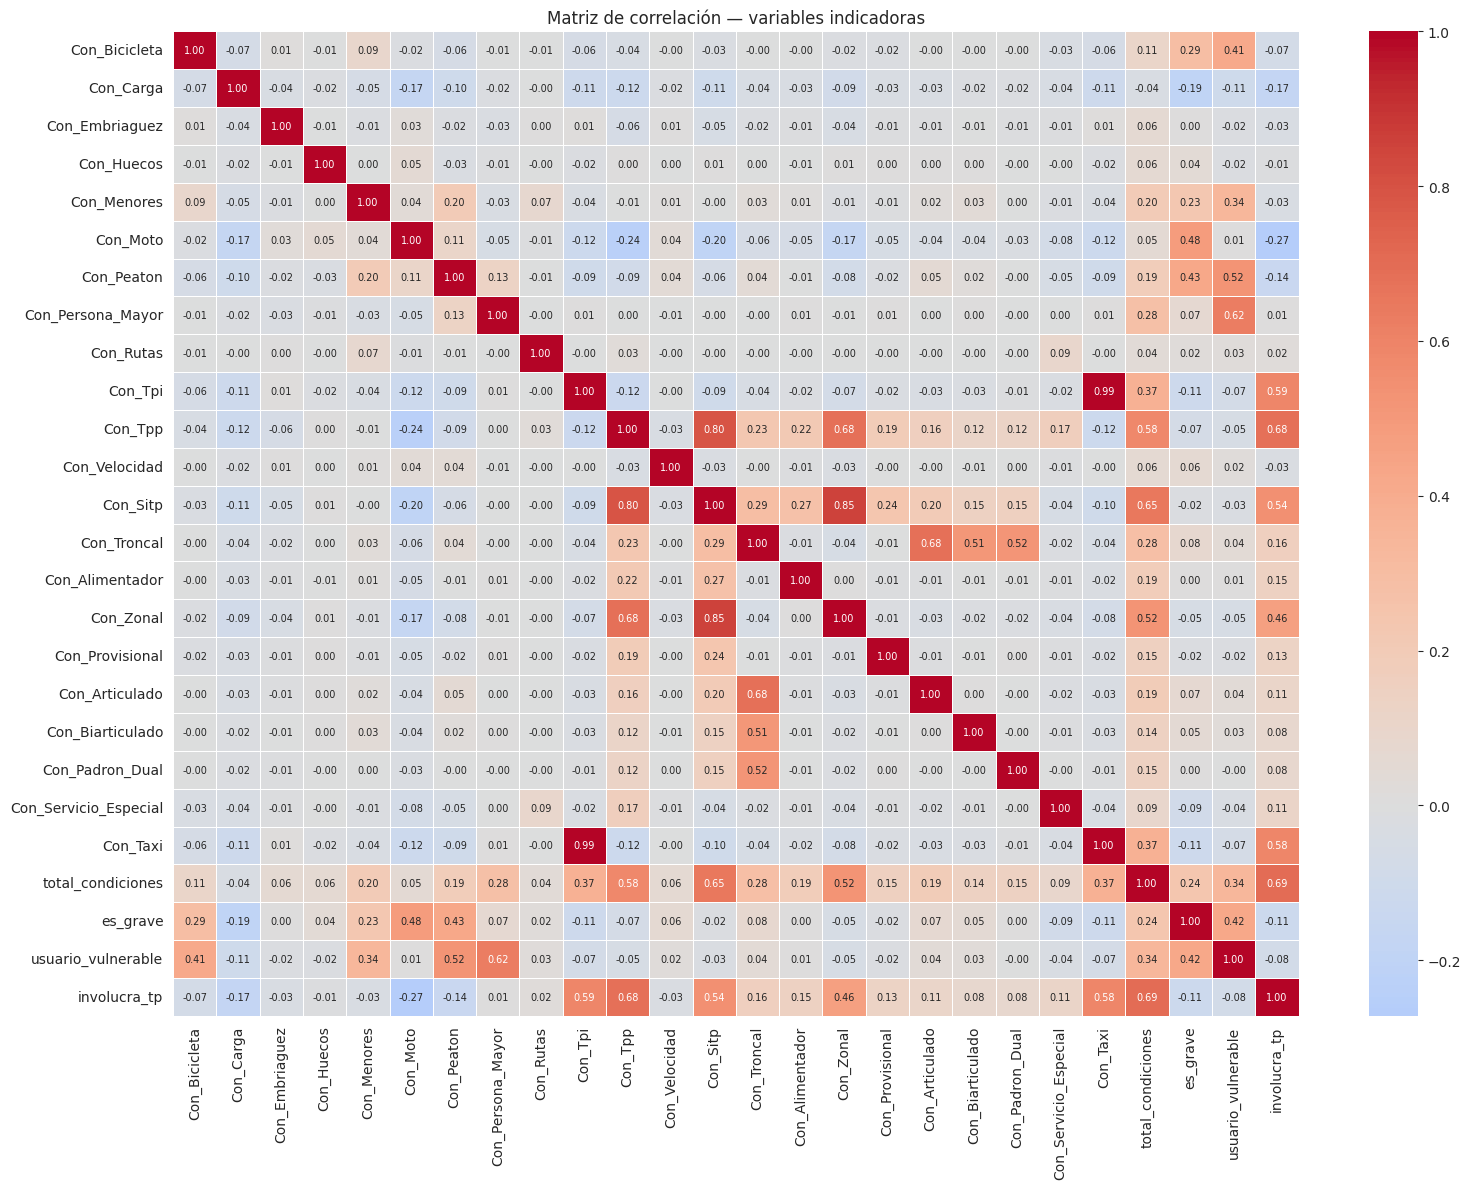

In [29]:
vars_corr = con_cols + ['total_condiciones', 'es_grave', 'usuario_vulnerable', 'involucra_tp']

corr_matrix = df_encoded[vars_corr].corr().round(3)

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Matriz de correlación — variables indicadoras')
plt.tight_layout()
plt.show()

# FASE 4 — Análisis Bivariado

En esta fase exploramos asociaciones entre la severidad (y/o `es_grave`) y variables indicadoras o categóricas. Se realizan: tablas de contingencia + prueba chi-cuadrado (con medida de efecto Cramér's V), y pruebas para comparar distribuciones de `Severidad_cod` o `total_condiciones` entre grupos (t-test / Mann-Whitney).

In [30]:
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu
import numpy as np

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1))) if min((kcorr-1),(rcorr-1))>0 else np.nan

# Lista de indicadores a evaluar vs gravedad/binaria
indicators = ['Con_Moto', 'Con_Peaton', 'Con_Embriaguez', 'Con_Bicicleta', 'Con_Taxi']

results = []
for ind in indicators:
    if ind not in df_encoded.columns:
        continue
    # Contingency table entre gravedad binaria y el indicador
    table = pd.crosstab(df_encoded['es_grave'], df_encoded[ind])
    chi2, p, dof, exp = chi2_contingency(table, correction=False)
    cv = cramers_v(table)
    results.append({'indicator': ind, 'chi2': chi2, 'p': p, 'cramers_v': cv})
    print(f'Indicador: {ind}')
    print(table)
    print(f'Chi2={chi2:.3f}, p={p:.4g}, CramersV={cv:.3f}')
    print('-'*60)

results_df = pd.DataFrame(results)
display(results_df)


Indicador: Con_Moto
Con_Moto      0      1
es_grave              
0         30531   3739
1         11380  14350
Chi2=14044.347, p=0, CramersV=0.484
------------------------------------------------------------
Indicador: Con_Peaton
Con_Peaton      0     1
es_grave               
0           34269     1
1           18506  7224
Chi2=10935.148, p=0, CramersV=0.427
------------------------------------------------------------
Indicador: Con_Embriaguez
Con_Embriaguez      0    1
es_grave                  
0               33535  735
1               25156  574
Chi2=0.511, p=0.4748, CramersV=0.000
------------------------------------------------------------
Indicador: Con_Bicicleta
Con_Bicicleta      0     1
es_grave                  
0              33906   364
1              21352  4378
Chi2=5138.465, p=0, CramersV=0.293
------------------------------------------------------------
Indicador: Con_Taxi
Con_Taxi      0     1
es_grave             
0         26655  7615
1         22219  3511
Chi2=71

,indicator,chi2,p,cramers_v
0,Con_Moto,14044.346579,0.000000e+00,0.483760
1,Con_Peaton,10935.148149,0.000000e+00,0.426843
2,Con_Embriaguez,0.510813,4.747872e-01,0.000000
3,Con_Bicicleta,5138.464648,0.000000e+00,0.292557
4,Con_Taxi,715.420930,1.325480e-157,0.109077


--- Motocicleta involucrada (Con_Moto) ---
T-test Welch: t=131.920, p=0
Mann-Whitney U: U=577008809.500, p=0


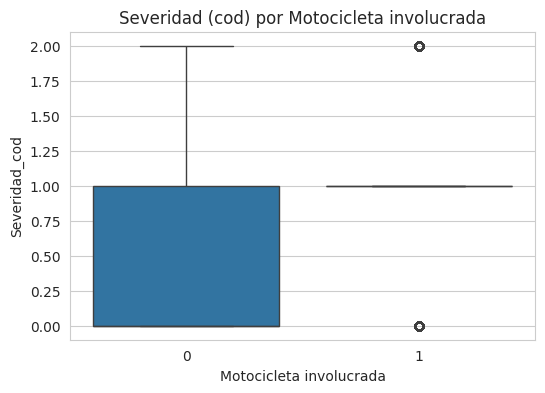

--- Peatón involucrado (Con_Peaton) ---
T-test Welch: t=191.657, p=0
Mann-Whitney U: U=316737401.500, p=0


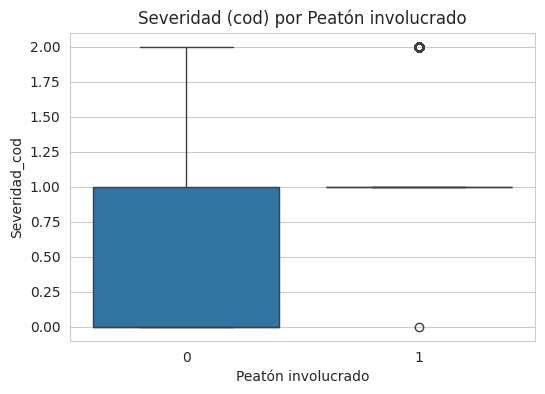

--- Embriaguez (Con_Embriaguez) ---
T-test Welch: t=1.947, p=0.05179
Mann-Whitney U: U=39135398.500, p=0.1769


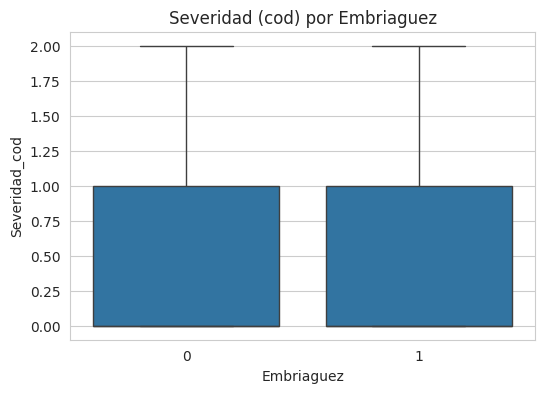

Kruskal-Wallis total_condiciones between es_grave groups:
Stat=3879.997, p=0


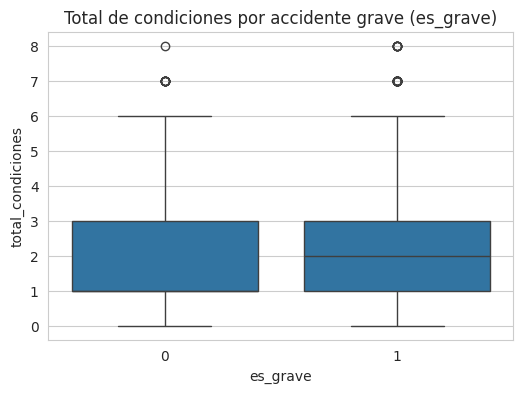

In [31]:
# Comparaciones de severidad numérica / total_condiciones entre grupos
comparisons = [('Con_Moto', 'Motocicleta involucrada'), ('Con_Peaton', 'Peatón involucrado'), ('Con_Embriaguez', 'Embriaguez') ]
for col, label in comparisons:
    if col not in df_encoded.columns:
        continue
    group1 = df_encoded.loc[df_encoded[col]==1, 'Gravedad_cod'].dropna()
    group0 = df_encoded.loc[df_encoded[col]==0, 'Gravedad_cod'].dropna()
    print(f'--- {label} ({col}) ---')
    # T-test Welch
    try:
        tstat, tp = ttest_ind(group1, group0, equal_var=False, nan_policy='omit')
        print(f'T-test Welch: t={tstat:.3f}, p={tp:.4g}')
    except Exception as e:
        print('T-test failed:', e)
    # Mann-Whitney (no paramétrica)
    try:
        ustat, up = mannwhitneyu(group1, group0, alternative='two-sided')
        print(f'Mann-Whitney U: U={ustat:.3f}, p={up:.4g}')
    except Exception as e:
        print('Mann-Whitney failed:', e)
    # Boxplot de severidad codificada
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df_encoded[col], y=df_encoded['Gravedad_cod'])
    plt.title(f'Severidad (cod) por {label}')
    plt.xlabel(label)
    plt.ylabel('Severidad_cod')
    plt.show()

# Comparación de total_condiciones por es_grave (Kruskal-Wallis)
from scipy.stats import kruskal
group_grave = df_encoded.loc[df_encoded['es_grave']==1, 'total_condiciones']
group_nograve = df_encoded.loc[df_encoded['es_grave']==0, 'total_condiciones']
print('Kruskal-Wallis total_condiciones between es_grave groups:')
try:
    kw_stat, kw_p = kruskal(group_grave, group_nograve)
    print(f'Stat={kw_stat:.3f}, p={kw_p:.4g}')
except Exception as e:
    print('Kruskal-Wallis failed:', e)
plt.figure(figsize=(6,4))
sns.boxplot(x='es_grave', y='total_condiciones', data=df_encoded)
plt.title('Total de condiciones por accidente grave (es_grave)')
plt.xlabel('es_grave')
plt.ylabel('total_condiciones')
plt.show()

/tmp/ipykernel_28765/4156397976.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultados_df, x='cramers_v', y='indicator', ax=axes[0], palette='Blues_r')
/tmp/ipykernel_28765/4156397976.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resultados_df, x='chi2', y='indicator', ax=axes[1], palette='Oranges_r')


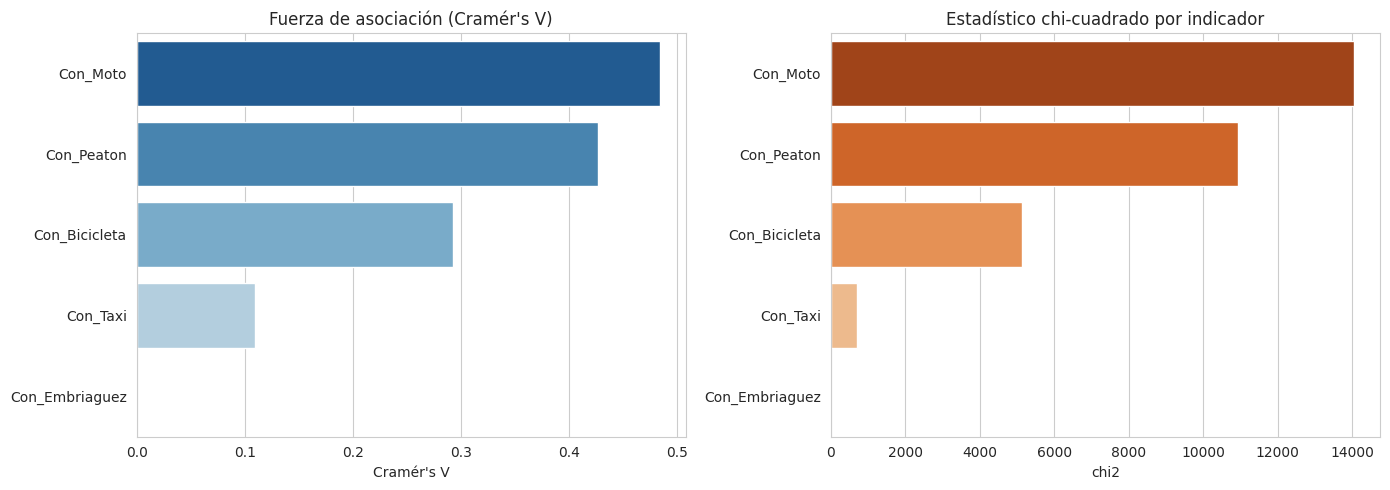

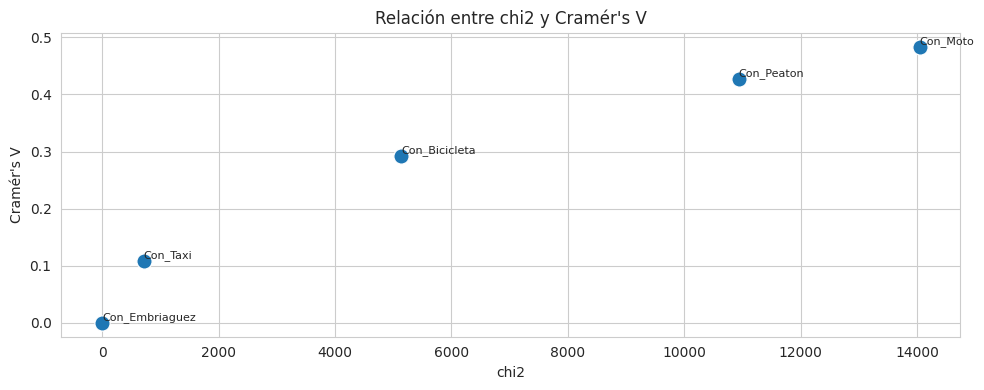

In [32]:
# Gráficos de la FASE 4: fuerza de asociación y distribución de factores
if results:
    resultados_df = pd.DataFrame(results).sort_values('cramers_v', ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=resultados_df, x='cramers_v', y='indicator', ax=axes[0], palette='Blues_r')
    axes[0].set_title('Fuerza de asociación (Cramér\'s V)')
    axes[0].set_xlabel('Cramér\'s V')
    axes[0].set_ylabel('')

    sns.barplot(data=resultados_df, x='chi2', y='indicator', ax=axes[1], palette='Oranges_r')
    axes[1].set_title('Estadístico chi-cuadrado por indicador')
    axes[1].set_xlabel('chi2')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.scatterplot(data=resultados_df, x='chi2', y='cramers_v', s=120, ax=ax)
    for _, row in resultados_df.iterrows():
        ax.text(row['chi2'], row['cramers_v'], row['indicator'], fontsize=8, ha='left', va='bottom')
    ax.set_title('Relación entre chi2 y Cramér\'s V')
    ax.set_xlabel('chi2')
    ax.set_ylabel('Cramér\'s V')
    plt.tight_layout()
    plt.show()
else:
    print('No hay resultados para graficar en FASE 4.')

,KPI,Fórmula,Valor,Interpretación,Importancia estratégica,Posible aplicación real,Visualización sugerida
0,Proporción de accidentes en Lunes,(# accidentes en Lunes / total de accidentes) ...,13.67%,El 13.67% de los accidentes ocurre en Lunes.,Permite detectar picos semanales de accidental...,Definir refuerzos de control y campañas por día.,Gráfico de barras por día de la semana.
1,Proporción de accidentes en Martes,(# accidentes en Martes / total de accidentes)...,15.24%,El 15.24% de los accidentes ocurre en Martes.,Permite detectar picos semanales de accidental...,Definir refuerzos de control y campañas por día.,Gráfico de barras por día de la semana.
2,Proporción de accidentes en Miércoles,(# accidentes en Miércoles / total de accident...,14.92%,El 14.92% de los accidentes ocurre en Miércoles.,Permite detectar picos semanales de accidental...,Definir refuerzos de control y campañas por día.,Gráfico de barras por día de la semana.
3,Proporción de accidentes en Jueves,(# accidentes en Jueves / total de accidentes)...,14.83%,El 14.83% de los accidentes ocurre en Jueves.,Permite detectar picos semanales de accidental...,Definir refuerzos de control y campañas por día.,Gráfico de barras por día de la semana.
4,Proporción de accidentes en Viernes,(# accidentes en Viernes / total de accidentes...,15.89%,El 15.89% de los accidentes ocurre en Viernes.,Permite detectar picos semanales de accidental...,Definir refuerzos de control y campañas por día.,Gráfico de barras por día de la semana.
5,Proporción de accidentes en Sábado,(# accidentes en Sábado / total de accidentes)...,15.14%,El 15.14% de los accidentes ocurre en Sábado.,Permite detectar picos semanales de accidental...,Definir refuerzos de control y campañas por día.,Gráfico de barras por día de la semana.
6,Proporción de accidentes en Domingo,(# accidentes en Domingo / total de accidentes...,10.32%,El 10.32% de los accidentes ocurre en Domingo.,Permite detectar picos semanales de accidental...,Definir refuerzos de control y campañas por día.,Gráfico de barras por día de la semana.
7,Porcentaje de accidentes con heridos,(accidentes con heridos / total de accidentes)...,41.06%,El 41.06% de los registros incluye heridos.,Resume el impacto humano del siniestro.,Priorizar prevención en zonas con mayor severi...,Barra comparativa de severidad.
8,Tasa de accidentes con motocicletas,(accidentes con Con_Moto = 1 / total de accide...,30.15%,El 30.15% de los accidentes involucra motocicl...,Identifica un grupo vial de alta exposición.,Diseñar controles y educación vial focalizada.,Barra de participación por tipo de vehículo.
9,Porcentaje de accidentes con peatones,(accidentes con Con_Peaton = 1 / total de acci...,12.04%,El 12.04% de los accidentes involucra peatones.,Mide riesgo para usuarios vulnerables de la vía.,"Ajustar pasos peatonales, cruces y señalización.",Barra de participación por actor vial.


/tmp/ipykernel_28765/1997626168.py:178: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_share.index, y=risk_share.values, ax=axes[1], palette='viridis')


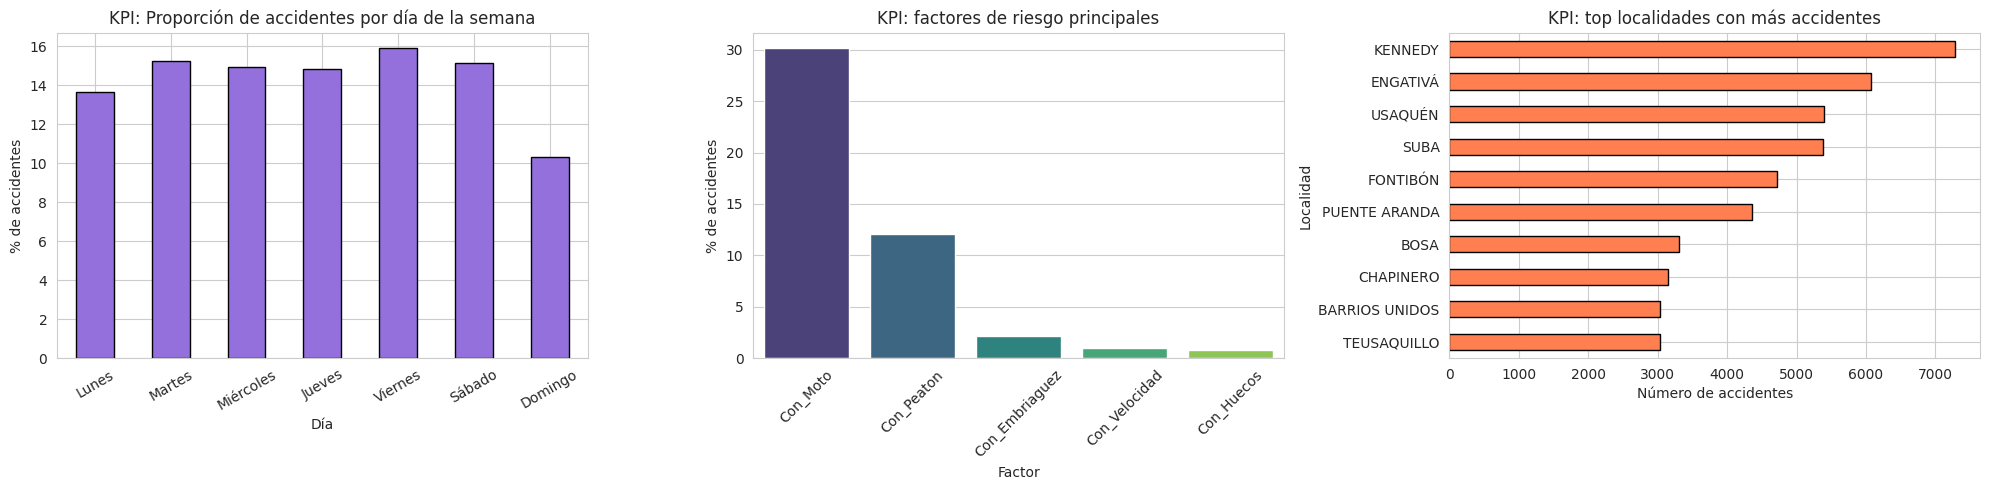

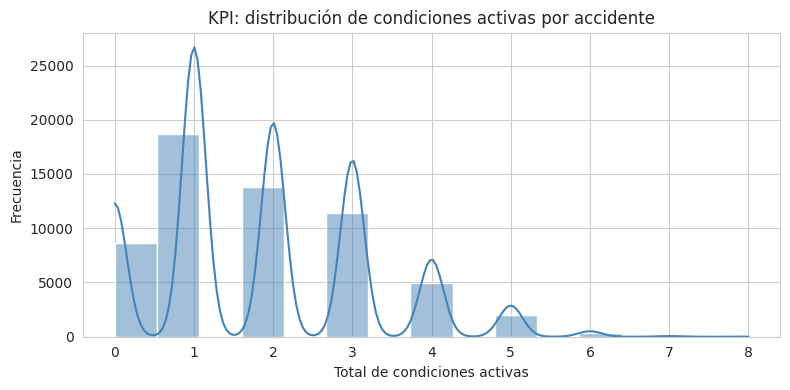

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_style('whitegrid')

rows = []
dias_orden = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']

def fmt_pct(value):
    return f"{value:.2f}%"

def add_row(kpi, formula, value, unidad, interpretacion, importancia, aplicacion, visualizacion):
    rows.append({
        'KPI': kpi,
        'Fórmula': formula,
        'Valor_num': value,
        'Unidad': unidad,
        'Interpretación': interpretacion,
        'Importancia estratégica': importancia,
        'Posible aplicación real': aplicacion,
        'Visualización sugerida': visualizacion,
    })

# 1) KPI de distribución por día de la semana
weekday_share = df_encoded['Dia_Semana_Acc'].value_counts(normalize=True).reindex(dias_orden).fillna(0) * 100
for dia in dias_orden:
    add_row(
        f'Proporción de accidentes en {dia}',
        f'(# accidentes en {dia} / total de accidentes) * 100',
        float(weekday_share.loc[dia]),
        '%',
        f'El {weekday_share.loc[dia]:.2f}% de los accidentes ocurre en {dia}.',
        'Permite detectar picos semanales de accidentalidad.',
        'Definir refuerzos de control y campañas por día.',
        'Gráfico de barras por día de la semana.'
    )

# 2) KPI de factores de riesgo y gravedad
pct_heridos = float(df_encoded['Gravedad_Indicador_Tradicional'].astype(str).str.contains('her', case=False, na=False).mean() * 100)
add_row(
    'Porcentaje de accidentes con heridos',
    '(accidentes con heridos / total de accidentes) * 100',
    pct_heridos,
    '%',
    f'El {pct_heridos:.2f}% de los registros incluye heridos.',
    'Resume el impacto humano del siniestro.',
    'Priorizar prevención en zonas con mayor severidad.',
    'Barra comparativa de severidad.'
)

pct_moto = float(df_encoded['Con_Moto'].mean() * 100) if 'Con_Moto' in df_encoded.columns else np.nan
add_row(
    'Tasa de accidentes con motocicletas',
    '(accidentes con Con_Moto = 1 / total de accidentes) * 100',
    pct_moto,
    '%',
    f'El {pct_moto:.2f}% de los accidentes involucra motocicletas.' if pd.notna(pct_moto) else 'La columna Con_Moto no está disponible.',
    'Identifica un grupo vial de alta exposición.',
    'Diseñar controles y educación vial focalizada.',
    'Barra de participación por tipo de vehículo.'
)

pct_peaton = float(df_encoded['Con_Peaton'].mean() * 100) if 'Con_Peaton' in df_encoded.columns else np.nan
add_row(
    'Porcentaje de accidentes con peatones',
    '(accidentes con Con_Peaton = 1 / total de accidentes) * 100',
    pct_peaton,
    '%',
    f'El {pct_peaton:.2f}% de los accidentes involucra peatones.' if pd.notna(pct_peaton) else 'La columna Con_Peaton no está disponible.',
    'Mide riesgo para usuarios vulnerables de la vía.',
    'Ajustar pasos peatonales, cruces y señalización.',
    'Barra de participación por actor vial.'
)

pct_embriaguez = float(df_encoded['Con_Embriaguez'].mean() * 100) if 'Con_Embriaguez' in df_encoded.columns else np.nan
add_row(
    'Porcentaje de accidentes asociados a embriaguez',
    '(accidentes con Con_Embriaguez = 1 / total de accidentes) * 100',
    pct_embriaguez,
    '%',
    f'El {pct_embriaguez:.2f}% de los accidentes reporta embriaguez.' if pd.notna(pct_embriaguez) else 'La columna Con_Embriaguez no está disponible.',
    'Es un indicador clave para controles preventivos.',
    'Planear operativos de alcoholemia y sanción.',
    'Barra de factores de riesgo.'
)

pct_velocidad = float(df_encoded['Con_Velocidad'].mean() * 100) if 'Con_Velocidad' in df_encoded.columns else np.nan
add_row(
    'Porcentaje de accidentes asociados a velocidad',
    '(accidentes con Con_Velocidad = 1 / total de accidentes) * 100',
    pct_velocidad,
    '%',
    f'El {pct_velocidad:.2f}% de los accidentes se asocia con velocidad.' if pd.notna(pct_velocidad) else 'La columna Con_Velocidad no está disponible.',
    'Ayuda a evaluar cultura de conducción y exceso de velocidad.',
    'Ubicar radares y campañas de control.',
    'Barra de factores de riesgo.'
)

pct_huecos = float(df_encoded['Con_Huecos'].mean() * 100) if 'Con_Huecos' in df_encoded.columns else np.nan
add_row(
    'Porcentaje de accidentes asociados a huecos',
    '(accidentes con Con_Huecos = 1 / total de accidentes) * 100',
    pct_huecos,
    '%',
    f'El {pct_huecos:.2f}% de los accidentes reporta huecos en la vía.' if pd.notna(pct_huecos) else 'La columna Con_Huecos no está disponible.',
    'Señala problemas de infraestructura vial.',
    'Priorizar mantenimiento y bacheo.',
    'Barra de factores de infraestructura.'
)

# 3) KPI de concentración por localidad
localidad_counts = df_encoded['Localidad'].value_counts()
if len(localidad_counts) > 0:
    top_localidad = str(localidad_counts.index[0])
    top_localidad_share = float(localidad_counts.iloc[0] / len(df_encoded) * 100)
else:
    top_localidad = 'N/D'
    top_localidad_share = np.nan
add_row(
    'Índice de accidentalidad por localidad (concentración líder)',
    '(accidentes en la localidad más frecuente / total de accidentes) * 100',
    top_localidad_share,
    '%',
    f'La localidad líder ({top_localidad}) concentra el {top_localidad_share:.2f}% de los accidentes.' if pd.notna(top_localidad_share) else 'No hay suficiente información de localidad.',
    'Permite ubicar puntos calientes de siniestralidad.',
    'Priorizar intervención territorial y patrullaje.',
    'Top 10 localidades en barras.'
)

# 4) KPI de gravedad alta
mask_grave = df_encoded['Gravedad_Indicador_Tradicional'].astype(str).str.contains(r'grave|fallec|fatal', case=False, regex=True, na=False)
pct_grave = float(mask_grave.mean() * 100)
add_row(
    'Porcentaje de accidentes graves o fatales',
    '(accidentes graves o fatales / total de accidentes) * 100',
    pct_grave,
    '%',
    f'El {pct_grave:.2f}% de los accidentes corresponde a casos graves o fatales.',
    'Es el KPI más cercano al impacto crítico en seguridad vial.',
    'Focalizar recursos en zonas y horarios de mayor severidad.',
    'Barra de severidad crítica.'
)

# 5) KPI de acumulación de condiciones
promedio_condiciones = float(df_encoded['total_condiciones'].mean()) if 'total_condiciones' in df_encoded.columns else np.nan
add_row(
    'Promedio de condiciones activas por accidente',
    'sumatoria de condiciones activas / total de accidentes',
    promedio_condiciones,
    'condiciones',
    f'Cada accidente presenta en promedio {promedio_condiciones:.2f} condiciones activas.' if pd.notna(promedio_condiciones) else 'No se pudo calcular el promedio de condiciones.',
    'Resume la complejidad multicausal del accidente.',
    'Diseñar intervenciones combinadas, no aisladas.',
    'Histograma o boxplot de total_condiciones.'
)

kpi_df = pd.DataFrame(rows)
kpi_df['Valor'] = kpi_df.apply(lambda r: fmt_pct(r['Valor_num']) if r['Unidad'] == '%' and pd.notna(r['Valor_num']) else (f"{r['Valor_num']:.2f}" if pd.notna(r['Valor_num']) else 'N/D'), axis=1)

kpi_show = kpi_df[['KPI', 'Fórmula', 'Valor', 'Interpretación', 'Importancia estratégica', 'Posible aplicación real', 'Visualización sugerida']]
display(kpi_show)

# Gráfico 1: distribución semanal
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
weekday_share.plot(kind='bar', ax=axes[0], color='mediumpurple', edgecolor='black')
axes[0].set_title('KPI: Proporción de accidentes por día de la semana')
axes[0].set_xlabel('Día')
axes[0].set_ylabel('% de accidentes')
axes[0].tick_params(axis='x', rotation=30)

# Gráfico 2: factores de riesgo principales
risk_cols = [col for col in ['Con_Moto', 'Con_Peaton', 'Con_Embriaguez', 'Con_Velocidad', 'Con_Huecos'] if col in df_encoded.columns]
if risk_cols:
    risk_share = (df_encoded[risk_cols].mean() * 100).sort_values(ascending=False)
    sns.barplot(x=risk_share.index, y=risk_share.values, ax=axes[1], palette='viridis')
    axes[1].set_title('KPI: factores de riesgo principales')
    axes[1].set_xlabel('Factor')
    axes[1].set_ylabel('% de accidentes')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].set_axis_off()
    axes[1].text(0.5, 0.5, 'No hay columnas de riesgo disponibles', ha='center', va='center')

# Gráfico 3: top localidades
if len(localidad_counts) > 0:
    localidad_counts.head(10).sort_values().plot(kind='barh', ax=axes[2], color='coral', edgecolor='black')
    axes[2].set_title('KPI: top localidades con más accidentes')
    axes[2].set_xlabel('Número de accidentes')
    axes[2].set_ylabel('Localidad')
else:
    axes[2].set_axis_off()
    axes[2].text(0.5, 0.5, 'No hay datos de localidad', ha='center', va='center')

plt.tight_layout()
plt.show()

# Gráfico adicional: condiciones activas
if 'total_condiciones' in df_encoded.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_encoded['total_condiciones'], bins=15, kde=True, color='steelblue')
    plt.title('KPI: distribución de condiciones activas por accidente')
    plt.xlabel('Total de condiciones activas')
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

## Interpretación (plantilla)

- **Indicadores con asociación estadísticamente significativa**: describir el indicador, dirección y fuerza (Cramér's V).
- **Comparaciones de severidad**: indicar si la severidad codificada es mayor en presencia del factor (reportar p-valor y tamaño del efecto).
- **Limitaciones**: recordar el sesgo de subregistro en columnas `Con_*` y que asociación no implica causalidad.

# FASE 5 — Preparación para Pruebas Inferenciales

Comprobación de supuestos (normalidad, homocedasticidad), tamaños muestrales por grupo, balance de clases y preparación de conjuntos para modelado.

In [34]:
from scipy.stats import shapiro, ks_2samp, levene, skew, kurtosis
import numpy as np

# Revisar conteos por clase
print('Conteo por Gravedad_cod:')
print(df_encoded['Gravedad_cod'].value_counts())
print('Conteo por es_grave (binaria):')
print(df_encoded['es_grave'].value_counts())

# Muestras y tamaños
group_sizes = df_encoded.groupby('Gravedad_cod').size()
print('Tamaños por grupo (Gravedad_cod):')
print(group_sizes)

# Normalidad de 'total_condiciones' (usar muestra aleatoria si es grande)
vals = df_encoded['total_condiciones'].dropna()
sample = vals.sample(n=min(5000, len(vals)), random_state=42)
stat, p = shapiro(sample) if len(sample) <= 5000 else (None, None)
if stat is not None:
    print(f"Shapiro 'total_condiciones' stat={stat:.3f}, p={p:.4g}")
else:
    print("Shapiro not run (sample > 5000). Use KS or rely on CLT for large samples.")

# Skewness / Kurtosis
print('Skewness total_condiciones:', skew(vals.dropna()))
print('Kurtosis total_condiciones:', kurtosis(vals.dropna()))

# Homocedasticidad: Levene across Gravedad groups for total_condiciones
groups = [grp['total_condiciones'].dropna() for _, grp in df_encoded.groupby('Gravedad_cod')]
try:
    lev_stat, lev_p = levene(*groups)
    print(f'Levene stat={lev_stat:.3f}, p={lev_p:.4g}')
except Exception as e:
    print('Levene failed:', e)

# Observaciones:
print('Observaciones:')
print('- Si p<0.05 en Shapiro/Levene, los supuestos no se cumplen y conviene usar pruebas no paramétricas o transformaciones.')
print('- La variable Gravedad_cod es ordinal y discreta; para comparaciones de medias no siempre es apropiada usar t-test sin considerar esto.')

Conteo por Gravedad_cod:
Gravedad_cod
0    34270
1    24637
2     1093
Name: count, dtype: int64
Conteo por es_grave (binaria):
es_grave
0    34270
1    25730
Name: count, dtype: int64
Tamaños por grupo (Gravedad_cod):
Gravedad_cod
0    34270
1    24637
2     1093
dtype: int64
Shapiro 'total_condiciones' stat=0.918, p=7.467e-46
Skewness total_condiciones: 0.5787242600810009
Kurtosis total_condiciones: -0.12724450084829098
Levene stat=67.695, p=4.299e-30
Observaciones:
- Si p<0.05 en Shapiro/Levene, los supuestos no se cumplen y conviene usar pruebas no paramétricas o transformaciones.
- La variable Gravedad_cod es ordinal y discreta; para comparaciones de medias no siempre es apropiada usar t-test sin considerar esto.


In [35]:
# Preparación de datos para modelado
from sklearn.model_selection import train_test_split

# Selección de predictores: indicadores Con_ + variables codificadas
feature_cols = [c for c in df_encoded.columns if c.startswith('Con_')] + ['total_condiciones', 'Dia_Semana_cod', 'Localidad_cod', 'Clase_Acc_cod', 'Elemento_Choque_cod']
# Asegurar que existan columnas seleccionadas
feature_cols = [c for c in feature_cols if c in df_encoded.columns]
print('Features seleccionadas (ejemplo):', feature_cols[:10])

# Target para clasificación (Accidente grave binario) y para regresión ordinal (Gravedad_cod)
X = df_encoded[feature_cols].copy()
y_clf = df_encoded['es_grave'].copy()
y_reg = df_encoded['Gravedad_cod'].copy()

# Balance de clases
print('Distribución target (es_grave):')
print(y_clf.value_counts(normalize=True) * 100)

# División estratificada para clasificación
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
print('Shapes (clasificación):', X_train_clf.shape, X_test_clf.shape)
print('Train class distribution:')
print(y_train_clf.value_counts(normalize=True) * 100)

# División para regresión (no estratificada por defecto)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)
print('Shapes (regresión):', X_train_reg.shape, X_test_reg.shape)

# Guardar conjuntos preparados opcionalmente
X_train_clf.to_csv('X_train_clf.csv', index=False)
X_test_clf.to_csv('X_test_clf.csv', index=False)
y_train_clf.to_csv('y_train_clf.csv', index=False)
y_test_clf.to_csv('y_test_clf.csv', index=False)
print('Conjuntos guardados: X_train_clf.csv, X_test_clf.csv, y_train_clf.csv, y_test_clf.csv')

Features seleccionadas (ejemplo): ['Con_Bicicleta', 'Con_Carga', 'Con_Embriaguez', 'Con_Huecos', 'Con_Menores', 'Con_Moto', 'Con_Peaton', 'Con_Persona_Mayor', 'Con_Rutas', 'Con_Tpi']
Distribución target (es_grave):
es_grave
0    57.116667
1    42.883333
Name: proportion, dtype: float64
Shapes (clasificación): (48000, 27) (12000, 27)
Train class distribution:
es_grave
0    57.116667
1    42.883333
Name: proportion, dtype: float64
Shapes (regresión): (48000, 27) (12000, 27)
Conjuntos guardados: X_train_clf.csv, X_test_clf.csv, y_train_clf.csv, y_test_clf.csv


**Checklist y siguientes pasos (FASE 5):
- Verificar tamaños muestrales por grupo (si son muy desbalanceados, considerar muestreo o pesos).
- Si normalidad/varianzas no se cumplen: usar pruebas no paramétricas o transformar `total_condiciones`.
- Preparar pipelines: codificación categórica, escalado (si aplica), y validación cruzada estratificada para clasificación.
- Continuar con FASE 6: pruebas de hipótesis específicas y construcción de modelos predictivos.

Variable: Con_Bicicleta — n=60000 — Shapiro(muestra aleatoria (n=5000)): stat=0.2902, p=6.582e-88 | KS (normal): stat=0.5370, p=0
  → Shapiro: evidencia para rechazar normalidad (p<=0.05) para la muestra analizada.
  → KS: evidencia contra normalidad (p<=0.05).


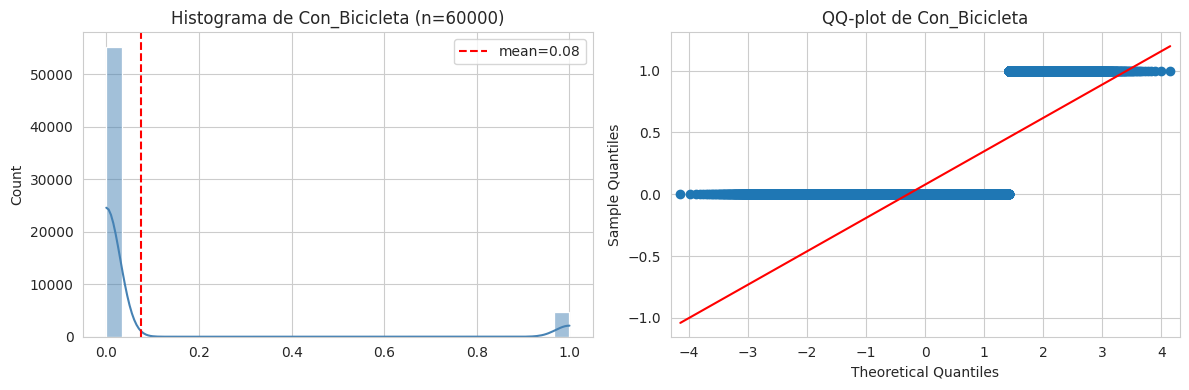



Variable: Con_Carga — n=60000 — Shapiro(muestra aleatoria (n=5000)): stat=0.3887, p=1.489e-84 | KS (normal): stat=0.5220, p=0
  → Shapiro: evidencia para rechazar normalidad (p<=0.05) para la muestra analizada.
  → KS: evidencia contra normalidad (p<=0.05).


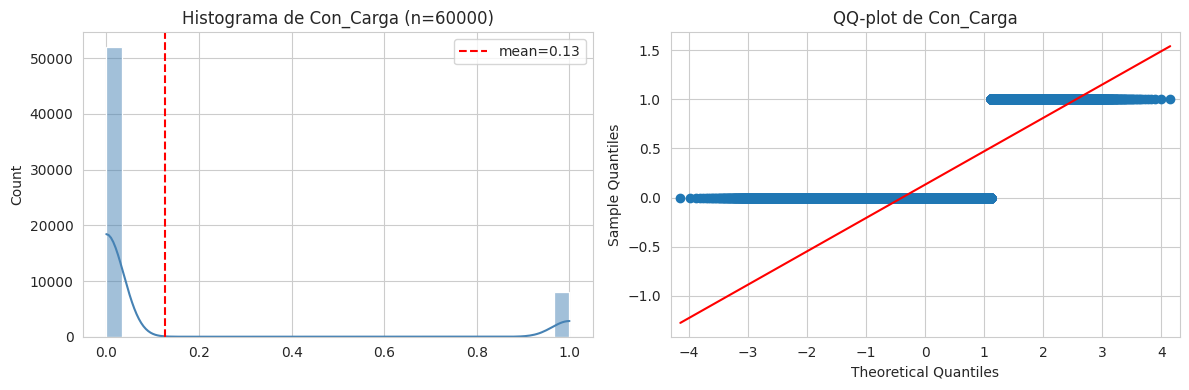



Variable: Con_Embriaguez — n=60000 — Shapiro(muestra aleatoria (n=5000)): stat=0.1152, p=5.652e-93 | KS (normal): stat=0.5363, p=0
  → Shapiro: evidencia para rechazar normalidad (p<=0.05) para la muestra analizada.
  → KS: evidencia contra normalidad (p<=0.05).


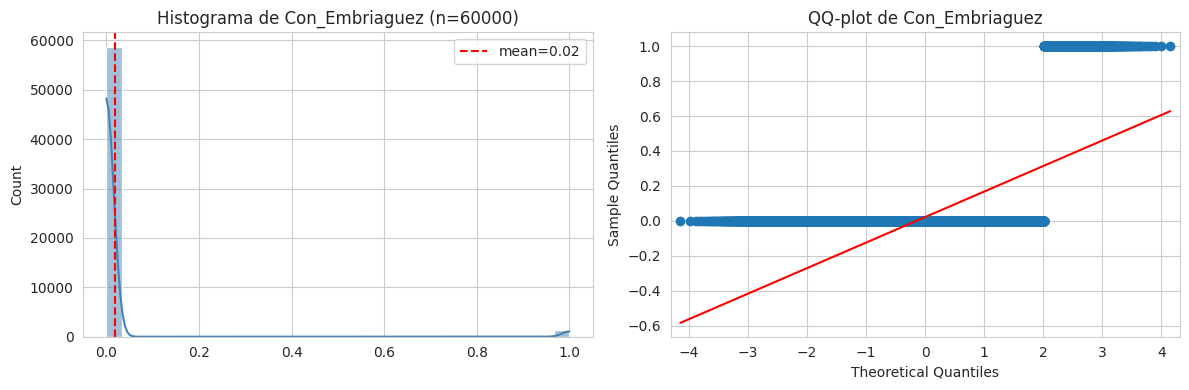



Variable: Con_Huecos — n=60000 — Shapiro(muestra aleatoria (n=5000)): stat=0.0605, p=2.226e-94 | KS (normal): stat=0.5278, p=0
  → Shapiro: evidencia para rechazar normalidad (p<=0.05) para la muestra analizada.
  → KS: evidencia contra normalidad (p<=0.05).


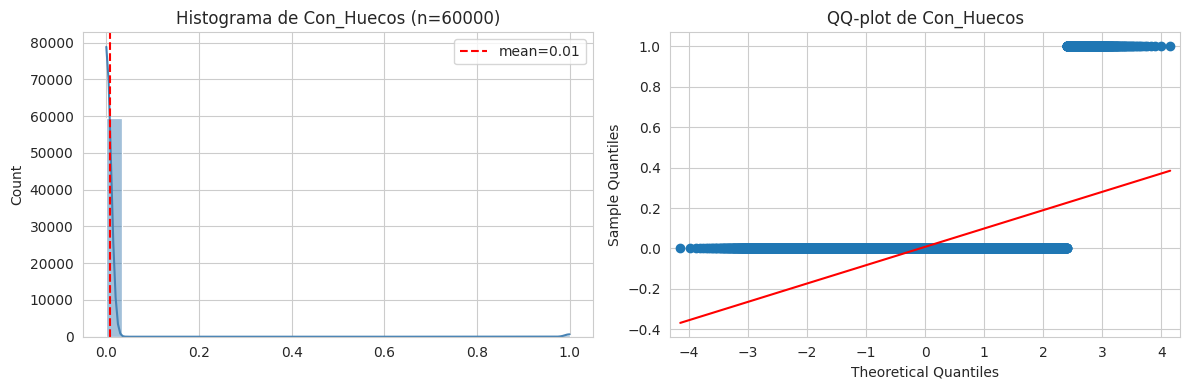



Variable: Con_Menores — n=60000 — Shapiro(muestra aleatoria (n=5000)): stat=0.2279, p=7.977e-90 | KS (normal): stat=0.5406, p=0
  → Shapiro: evidencia para rechazar normalidad (p<=0.05) para la muestra analizada.
  → KS: evidencia contra normalidad (p<=0.05).


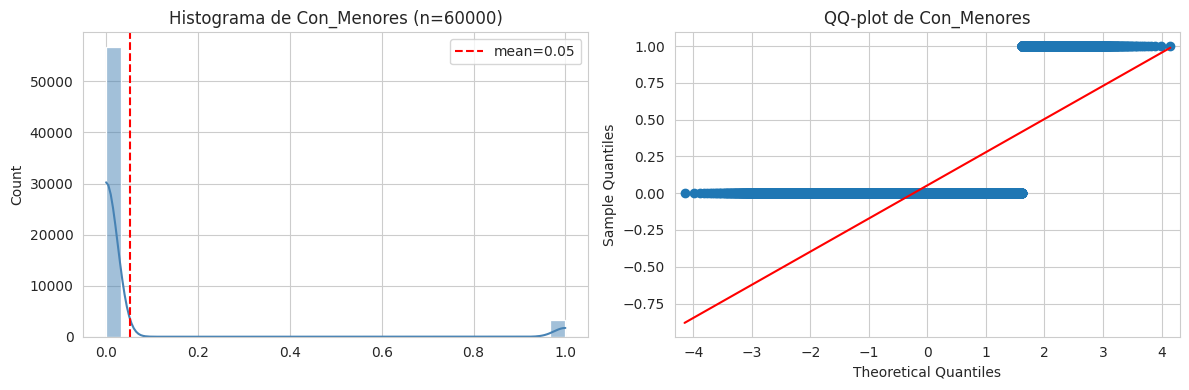



Variable: Con_Moto — n=60000 — Shapiro(muestra aleatoria (n=5000)): stat=0.5769, p=1.407e-76 | KS (normal): stat=0.4427, p=0
  → Shapiro: evidencia para rechazar normalidad (p<=0.05) para la muestra analizada.
  → KS: evidencia contra normalidad (p<=0.05).


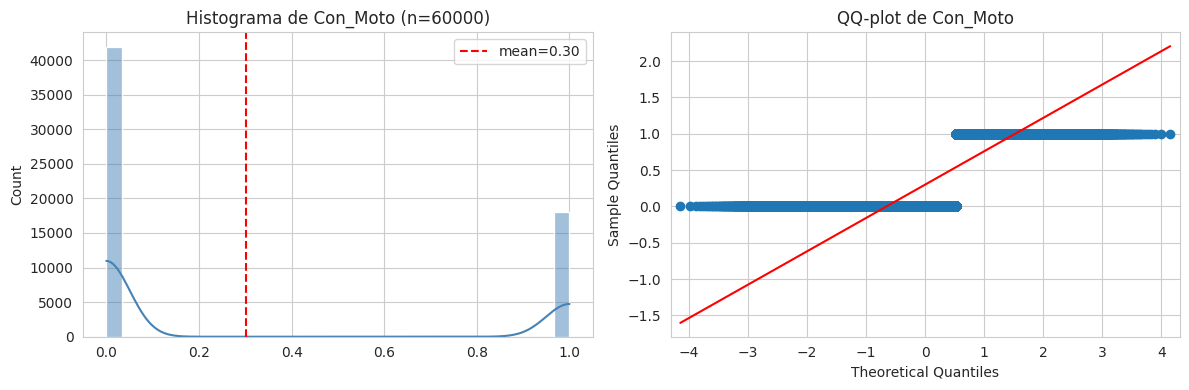

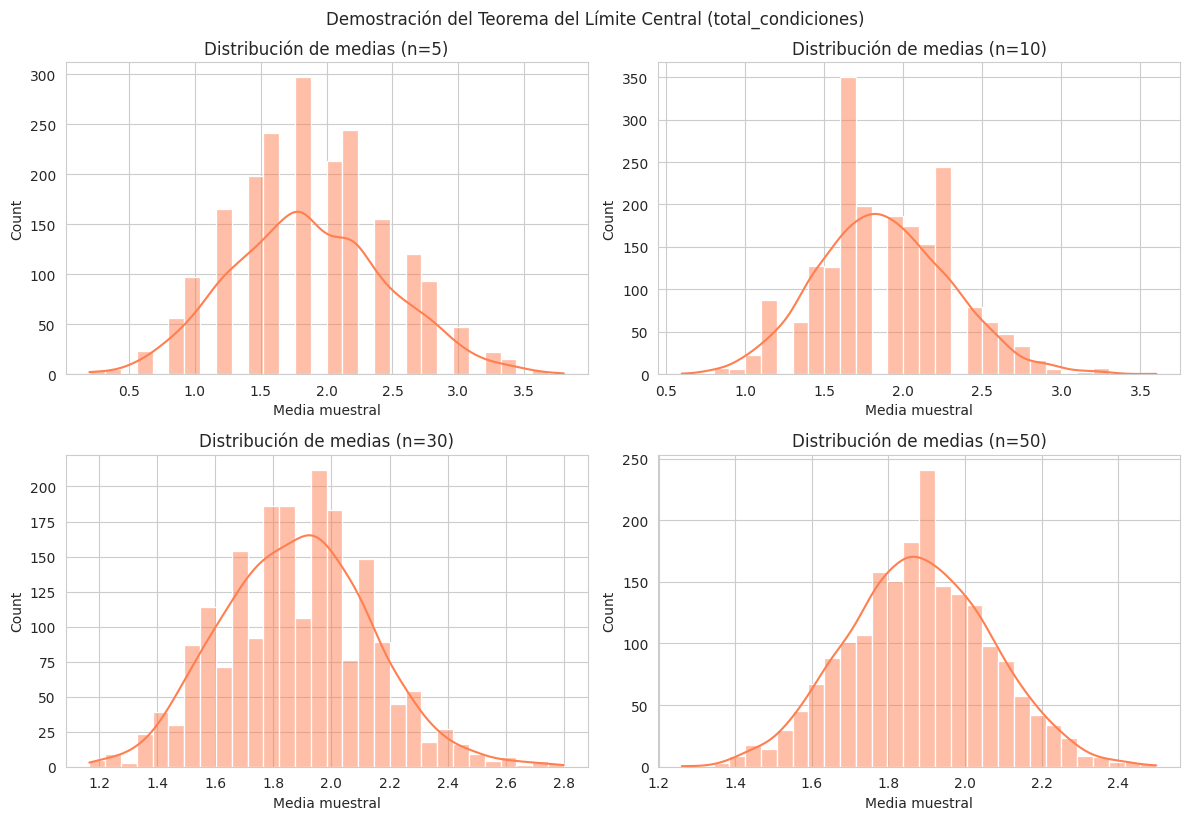


**Interpretación crítica obligatoria**

- Por qué la normalidad es importante: muchas pruebas estadísticas (t-test, ANOVA, regresión lineal clásica)
  asumen normalidad de los errores o de las variables para que los estimadores tengan propiedades óptimas y
  para que las pruebas de significancia tengan validez.

- Riesgos de usar pruebas paramétricas sin normalidad: p-values pueden ser incorrectos, errores tipo I/II
  aumentan, intervalos de confianza no son confiables. Pueden llevar a decisiones erróneas en política pública.

- Implicaciones del tamaño de la muestra: con muestras pequeñas las pruebas tienen baja potencia; con muestras
  muy grandes incluso pequeñas desviaciones de normalidad generan p-values muy pequeños (rechazo de H0),
  por lo que la interpretación debe considerar magnitud del efecto y gráficos.

- Por qué datasets grandes pueden aparentar normalidad: el Teorema del Límite Central explica que la distribución
  de medias muestrales tiende a normal, pero variables individuales pueden seguir distribuciones sesgadas; además,
  procesos de agregación y mezcla de subpoblaciones pueden suavizar la forma observada.

**Discusión profunda**

- ¿La estadística clásica siempre representa fenómenos reales? No necesariamente; es una aproximación con supuestos que
  deben validarse. En fenómenos complejos y sesgados conviene usar métodos robustos o no paramétricos.

- ¿La normalidad es real o una simplificación útil? Es una simplificación matemática muy útil; en muchos casos ayuda
  pero no reemplaza el juicio crítico y la verificación empírica.


In [55]:
# FASE 5 — Teorema del Límite Central y Normalidad
from scipy.stats import shapiro, kstest
from scipy import stats
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_style('whitegrid')

# Selección de variables numéricas (fallback si vars_numericas no existe)
try:
    numeric_vars = vars_numericas
except NameError:
    numeric_vars = df_encoded.select_dtypes(include=[np.number]).columns.tolist()

numeric_vars = [v for v in numeric_vars if v not in ['index']]

results = []

for var in numeric_vars[:6]:  # limitar a las primeras 6 para no saturar la salida
    arr = df_encoded[var].dropna().values
    n = len(arr)
    if n == 0:
        continue
    # Para Shapiro: usar muestra si n > 5000
    if n > 5000:
        samp = np.random.choice(arr, size=5000, replace=False)
        sh_target = 'muestra aleatoria (n=5000)'
    else:
        samp = arr
        sh_target = f'n={n}'

    sh_stat, sh_p = shapiro(samp)
    mean, std = samp.mean(), samp.std(ddof=0)
    # Normalizar para KS
    ks_stat, ks_p = kstest((samp - mean) / std, 'norm')

    results.append((var, n, sh_stat, sh_p, ks_stat, ks_p, mean, std))

    # Mostrar e interpretar
    print(f"Variable: {var} — n={n} — Shapiro({sh_target}): stat={sh_stat:.4f}, p={sh_p:.4g} | KS (normal): stat={ks_stat:.4f}, p={ks_p:.4g}")
    if sh_p > 0.05:
        print("  → Shapiro: no se rechaza normalidad (p>0.05) para la muestra analizada.")
    else:
        print("  → Shapiro: evidencia para rechazar normalidad (p<=0.05) para la muestra analizada.")
    if ks_p > 0.05:
        print("  → KS: consistente con normalidad (p>0.05).")
    else:
        print("  → KS: evidencia contra normalidad (p<=0.05).")

    # Gráficos: histograma + QQ-plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(arr, bins=30, kde=True, ax=axes[0], color='steelblue')
    axes[0].axvline(mean, color='red', linestyle='--', label=f'mean={mean:.2f}')
    axes[0].set_title(f'Histograma de {var} (n={n})')
    axes[0].legend()

    sm.qqplot(arr, line='s', ax=axes[1])
    axes[1].set_title(f'QQ-plot de {var}')

    plt.tight_layout()
    plt.show()
    print('\n')

# Demostración del Teorema del Límite Central con la variable 'total_condiciones' si existe
if 'total_condiciones' in df_encoded.columns:
    var = 'total_condiciones'
    pop = df_encoded[var].dropna().values
    plt.figure(figsize=(12, 8))
    sample_sizes = [5, 10, 30, 50]
    for i, s in enumerate(sample_sizes, 1):
        means = [np.mean(np.random.choice(pop, size=s, replace=True)) for _ in range(2000)]
        plt.subplot(2, 2, i)
        sns.histplot(means, bins=30, kde=True, color='coral')
        plt.title(f'Distribución de medias (n={s})')
        plt.xlabel('Media muestral')
    plt.tight_layout()
    plt.suptitle('Demostración del Teorema del Límite Central (total_condiciones)', y=1.02)
    plt.show()

# Resumen de interpretación crítica y preguntas obligatorias
md = '''
**Interpretación crítica obligatoria**

- Por qué la normalidad es importante: muchas pruebas estadísticas (t-test, ANOVA, regresión lineal clásica)
  asumen normalidad de los errores o de las variables para que los estimadores tengan propiedades óptimas y
  para que las pruebas de significancia tengan validez.

- Riesgos de usar pruebas paramétricas sin normalidad: p-values pueden ser incorrectos, errores tipo I/II
  aumentan, intervalos de confianza no son confiables. Pueden llevar a decisiones erróneas en política pública.

- Implicaciones del tamaño de la muestra: con muestras pequeñas las pruebas tienen baja potencia; con muestras
  muy grandes incluso pequeñas desviaciones de normalidad generan p-values muy pequeños (rechazo de H0),
  por lo que la interpretación debe considerar magnitud del efecto y gráficos.

- Por qué datasets grandes pueden aparentar normalidad: el Teorema del Límite Central explica que la distribución
  de medias muestrales tiende a normal, pero variables individuales pueden seguir distribuciones sesgadas; además,
  procesos de agregación y mezcla de subpoblaciones pueden suavizar la forma observada.

**Discusión profunda**

- ¿La estadística clásica siempre representa fenómenos reales? No necesariamente; es una aproximación con supuestos que
  deben validarse. En fenómenos complejos y sesgados conviene usar métodos robustos o no paramétricos.

- ¿La normalidad es real o una simplificación útil? Es una simplificación matemática muy útil; en muchos casos ayuda
  pero no reemplaza el juicio crítico y la verificación empírica.
'''

display(Markdown(md))

# FASE 6 — Pruebas de Hipótesis (específicas)

Aplicar pruebas dirigidas acorde al enunciado: más chi-cuadrado, pruebas de diferencia de medias y pruebas no paramétricas según corresponda.

In [36]:
# Ejemplo: ejecutar chi-cuadrado para todas las columnas Con_ vs es_grave y listar significativas
from scipy.stats import chi2_contingency
import numpy as np
significant = []
for col in [c for c in df_encoded.columns if c.startswith('Con_')]:
    table = pd.crosstab(df_encoded['es_grave'], df_encoded[col])
    try:
        chi2, p, dof, exp = chi2_contingency(table, correction=False)
        cv = cramers_v(table)
        if p < 0.05:
            significant.append({'variable': col, 'p': p, 'cramers_v': cv})
    except Exception as e:
        pass
significant_df = pd.DataFrame(significant).sort_values('p').head(20)
display(significant_df)


,variable,p,cramers_v
0,Con_Bicicleta,0.000000e+00,0.292557
1,Con_Carga,0.000000e+00,0.193250
3,Con_Menores,0.000000e+00,0.224670
4,Con_Moto,0.000000e+00,0.483760
5,Con_Peaton,0.000000e+00,0.426843
8,Con_Tpi,2.933388e-162,0.110700
18,Con_Taxi,1.325480e-157,0.109077
17,Con_Servicio_Especial,3.778188e-98,0.085655
12,Con_Troncal,1.323786e-79,0.076887
15,Con_Articulado,3.302345e-66,0.069855


/tmp/ipykernel_28765/2391141027.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=significant_df, x='cramers_v', y='variable', ax=axes[0], palette='Greens_r')


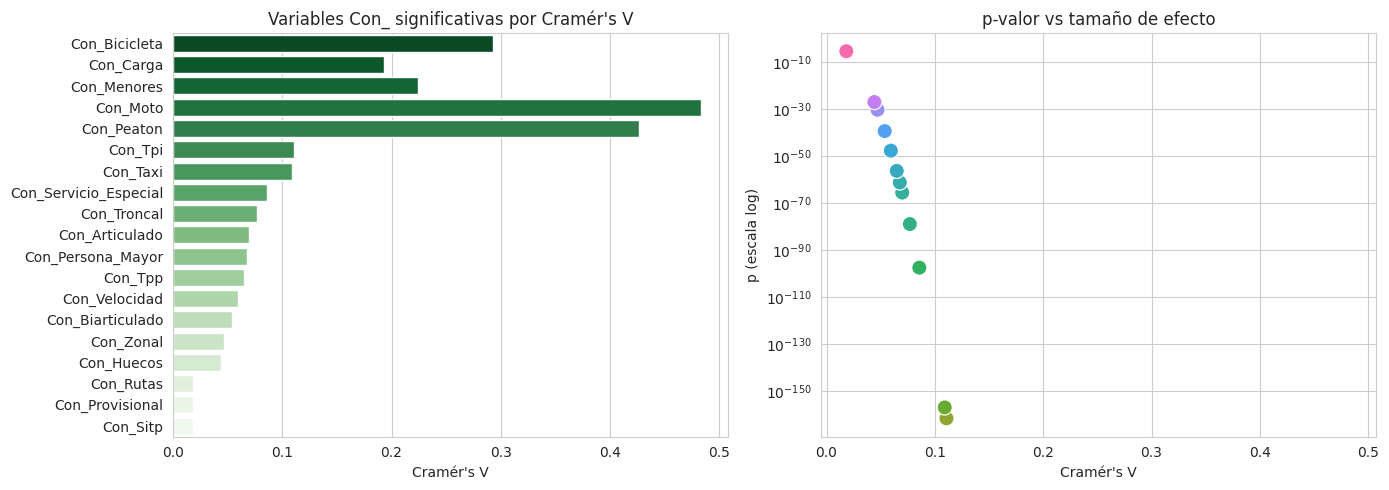

In [37]:
# Visualizaciones de la FASE 6: variables con asociación significativa
significant_df = pd.DataFrame(significant)
if not significant_df.empty:
    significant_df = significant_df.sort_values('p')
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(data=significant_df, x='cramers_v', y='variable', ax=axes[0], palette='Greens_r')
    axes[0].set_title('Variables Con_ significativas por Cramér\'s V')
    axes[0].set_xlabel('Cramér\'s V')
    axes[0].set_ylabel('')

    sns.scatterplot(data=significant_df, x='cramers_v', y='p', hue='variable', s=120, ax=axes[1], legend=False)
    axes[1].set_yscale('log')
    axes[1].set_title('p-valor vs tamaño de efecto')
    axes[1].set_xlabel('Cramér\'s V')
    axes[1].set_ylabel('p (escala log)')

    plt.tight_layout()
    plt.show()
else:
    print('No se encontraron variables significativas para graficar en FASE 6.')

In [56]:
# FASE 6 — Distribuciones y Pruebas de Hipótesis
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

# Funciones auxiliares
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r,k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

def cohens_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx-1)*np.std(x, ddof=1)**2 + (ny-1)*np.std(y, ddof=1)**2) / dof)
    if pooled_std == 0:
        return np.nan
    return (np.mean(x) - np.mean(y)) / pooled_std

# Hipótesis de ejemplo 1: Con_Moto vs Gravedad
print('Hipótesis 1: H0: la presencia de motocicletas no influye en la severidad. H1: sí influye.')
if 'Con_Moto' in df_encoded.columns and 'Gravedad_Indicador_Tradicional' in df_encoded.columns:
    cont = pd.crosstab(df_encoded['Con_Moto'], df_encoded['Gravedad_Indicador_Tradicional'])
    print('\nTabla de contingencia (Con_Moto x Gravedad):')
    display(cont)
    chi2, p, dof, ex = chi2_contingency(cont)
    cv = cramers_v(cont)
    print(f'Chi2={chi2:.3f}, p={p:.4g}, dof={dof}, Cramer\'s V={cv:.3f}')
    print('Interpretación:')
    if p <= 0.05:
        print(' - Estadísticamente significativa (p<=0.05): hay evidencia de asociación.')
    else:
        print(' - No se rechaza H0 con este criterio (p>0.05): no hay evidencia suficiente de asociación).')
    print(' - Tamaño de efecto (Cramer\'s V):', cv)
else:
    print('Columnas necesarias para la hipótesis 1 no están disponibles.')

# Hipótesis 2: Con_Embriaguez vs alguna métrica numérica (total_condiciones)
print('\nHipótesis 2: H0: accidentes con embriaguez no difieren en total_condiciones.')
if 'Con_Embriaguez' in df_encoded.columns and 'total_condiciones' in df_encoded.columns:
    group1 = df_encoded.loc[df_encoded['Con_Embriaguez']==1, 'total_condiciones'].dropna()
    group0 = df_encoded.loc[df_encoded['Con_Embriaguez']==0, 'total_condiciones'].dropna()
    print(f'n_embriaguez={len(group1)}, n_no={len(group0)}')
    # Test de normalidad rápido para decidir prueba
    stat1, p1 = stats.shapiro(group1.sample(5000) if len(group1)>5000 else group1)
    stat0, p0 = stats.shapiro(group0.sample(5000) if len(group0)>5000 else group0)
    print(f'Shapiro p (embriaguez)={p1:.4g}, Shapiro p (no embriaguez)={p0:.4g}')
    # Usar t-test si ambos normales y tamaños adecuados, si no -> Mann-Whitney
    use_t = (p1>0.05) and (p0>0.05) and len(group1)>30 and len(group0)>30
    if use_t:
        tstat, tp = stats.ttest_ind(group1, group0, equal_var=False)
        effect = cohens_d(group1, group0)
        print(f't-test: t={tstat:.3f}, p={tp:.4g}, Cohen\'s d={effect:.3f}')
    else:
        ustat, up = stats.mannwhitneyu(group1, group0, alternative='two-sided')
        # compute a nonparametric effect size (rank-biserial)
        n1, n2 = len(group1), len(group0)
        rb = 1 - (2*ustat)/(n1*n2)
        print(f'Mann-Whitney U={ustat}, p={up:.4g}, Rank-biserial={rb:.3f}')
    print('\nInterpretación:')
    print(' - No acepte solo "p<0.05"; analice magnitud del efecto, sesgos y relevancia práctica.')
else:
    print('Columnas necesarias para la hipótesis 2 no están disponibles.')

# Explicar errores tipo I y II y decisiones
print('\nErrores estadísticos y decisiones:')
print(' - Error tipo I (α): rechazar H0 cuando es verdadera. Ex.: asignar recursos por falso positivo.')
print(' - Error tipo II (β): no rechazar H0 cuando H1 es verdadera. Ex.: no detectar una intervención necesaria.')
print(' - Relación entre tamaño muestral y errores: muestras grandes reducen β, pero pueden detectar diferencias triviales (significancia práctica vs estadística).')

# Recomendaciones prácticas
print('\nRecomendaciones:')
print('- Reportar p-value, intervalo de confianza y tamaño del efecto.')
print('- Usar pruebas no paramétricas si no se cumplen supuestos.')
print('- Considerar sesgos de registro y composición de subpoblaciones.')
print('- Complementar con análisis gráfico y replicación por subgrupos.')

Hipótesis 1: H0: la presencia de motocicletas no influye en la severidad. H1: sí influye.

Tabla de contingencia (Con_Moto x Gravedad):


Gravedad_Indicador_Tradicional,Solo Daños,Con Heridos,Con Muertos
Con_Moto,,,
0,30531,10909,471
1,3739,13728,622


Chi2=14045.046, p=0, dof=2, Cramer's V=0.484
Interpretación:
 - Estadísticamente significativa (p<=0.05): hay evidencia de asociación.
 - Tamaño de efecto (Cramer's V): 0.4838223887170016

Hipótesis 2: H0: accidentes con embriaguez no difieren en total_condiciones.
n_embriaguez=1309, n_no=58691
Shapiro p (embriaguez)=7.705e-30, Shapiro p (no embriaguez)=2.242e-46
Mann-Whitney U=47657971.0, p=4.942e-53, Rank-biserial=-0.241

Interpretación:
 - No acepte solo "p<0.05"; analice magnitud del efecto, sesgos y relevancia práctica.

Errores estadísticos y decisiones:
 - Error tipo I (α): rechazar H0 cuando es verdadera. Ex.: asignar recursos por falso positivo.
 - Error tipo II (β): no rechazar H0 cuando H1 es verdadera. Ex.: no detectar una intervención necesaria.
 - Relación entre tamaño muestral y errores: muestras grandes reducen β, pero pueden detectar diferencias triviales (significancia práctica vs estadística).

Recomendaciones:
- Reportar p-value, intervalo de confianza y tamaño del 

# FASE 7 — ANOVA y pruebas post-hoc

Evaluar diferencias de `Severidad_cod` entre localidades o clases; si ANOVA significativa, aplicar comparaciones por pares (Tukey HSD).

In [38]:
from scipy.stats import f_oneway
# ANOVA entre top 5 localidades
top_local = df_encoded['Localidad'].value_counts().head(5).index.tolist()
groups = [df_encoded.loc[df_encoded['Localidad']==loc, 'Gravedad_cod'].dropna() for loc in top_local]
try:
    fstat, fp = f_oneway(*groups)
    print(f'ANOVA F={fstat:.3f}, p={fp:.4g}')
except Exception as e:
    print('ANOVA failed:', e)
anova_table = pd.DataFrame({'Localidad': top_local, 'Media_Gravedad_cod': [df_encoded.loc[df_encoded['Localidad']==loc, 'Gravedad_cod'].mean() for loc in top_local], 'N': [df_encoded.loc[df_encoded['Localidad']==loc, 'Gravedad_cod'].dropna().shape[0] for loc in top_local]})
display(anova_table)
# Post-hoc (Tukey) — usar statsmodels si está disponible
try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    tuk = pairwise_tukeyhsd(df_encoded['Gravedad_cod'], df_encoded['Localidad'])
    tukey_table = pd.DataFrame(tuk.summary().data[1:], columns=tuk.summary().data[0])
    display(tukey_table)
except Exception as e:
    print('Tukey HSD not available (install statsmodels) or failed:', e)


ANOVA F=195.463, p=1.164e-165


,Localidad,Media_Gravedad_cod,N
0,KENNEDY,0.524248,7279
1,ENGATIVÁ,0.411600,6069
2,USAQUÉN,0.274092,5396
3,SUBA,0.434605,5375
4,FONTIBÓN,0.360280,4713


,group1,group2,meandiff,p-adj,lower,upper,reject
0,ANTONIO NARIÑO,BARRIOS UNIDOS,-0.1986,0.0000,-0.2613,-0.1359,True
1,ANTONIO NARIÑO,BOSA,0.0208,0.9998,-0.0411,0.0827,False
2,ANTONIO NARIÑO,CANDELARIA,-0.0916,0.4316,-0.2120,0.0288,False
3,ANTONIO NARIÑO,CHAPINERO,-0.2426,0.0000,-0.3049,-0.1802,True
4,ANTONIO NARIÑO,CIUDAD BOLÍVAR,0.0358,0.9207,-0.0291,0.1006,False
...,...,...,...,...,...,...,...
185,TEUSAQUILLO,USAQUÉN,-0.0910,0.0000,-0.1331,-0.0490,True
186,TEUSAQUILLO,USME,0.2308,0.0000,0.1694,0.2921,True
187,TUNJUELITO,USAQUÉN,-0.2600,0.0000,-0.3116,-0.2083,True
188,TUNJUELITO,USME,0.0618,0.1366,-0.0065,0.1301,False


/tmp/ipykernel_28765/2864401918.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=anova_df, x='Localidad', y='Gravedad_cod', order=top_local, ax=axes[0], palette='Set2')
/tmp/ipykernel_28765/2864401918.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_plot.index, y=mean_plot.values, ax=axes[1], palette='Set3')


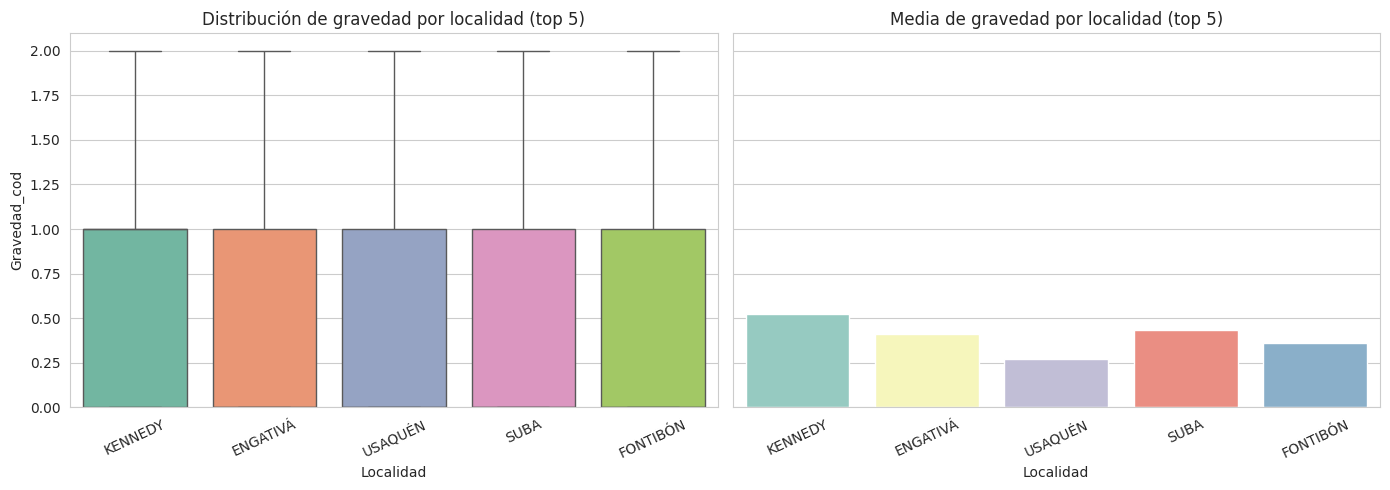

In [39]:
# Visualizaciones de la FASE 7: boxplot y medias para las localidades analizadas
if top_local:
    anova_df = df_encoded[df_encoded['Localidad'].isin(top_local)].copy()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    sns.boxplot(data=anova_df, x='Localidad', y='Gravedad_cod', order=top_local, ax=axes[0], palette='Set2')
    axes[0].set_title('Distribución de gravedad por localidad (top 5)')
    axes[0].set_xlabel('Localidad')
    axes[0].set_ylabel('Gravedad_cod')
    axes[0].tick_params(axis='x', rotation=25)

    mean_plot = anova_df.groupby('Localidad', observed=False)['Gravedad_cod'].mean().reindex(top_local)
    sns.barplot(x=mean_plot.index, y=mean_plot.values, ax=axes[1], palette='Set3')
    axes[1].set_title('Media de gravedad por localidad (top 5)')
    axes[1].set_xlabel('Localidad')
    axes[1].set_ylabel('Media Gravedad_cod')
    axes[1].tick_params(axis='x', rotation=25)

    plt.tight_layout()
    plt.show()
else:
    print('No hay localidades suficientes para graficar en FASE 7.')

n_moto=18089, n_no=41911
Shapiro moto p=1.863e-58, Shapiro no p=8.289e-47, Levene p=0
Mann-Whitney U=415165042.5, p=5.985e-81, rank-biserial=-0.095


/tmp/ipykernel_28765/3837539556.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Sin Moto', 'Con Moto'])
/tmp/ipykernel_28765/3837539556.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Sin Moto', 'Con Moto'])


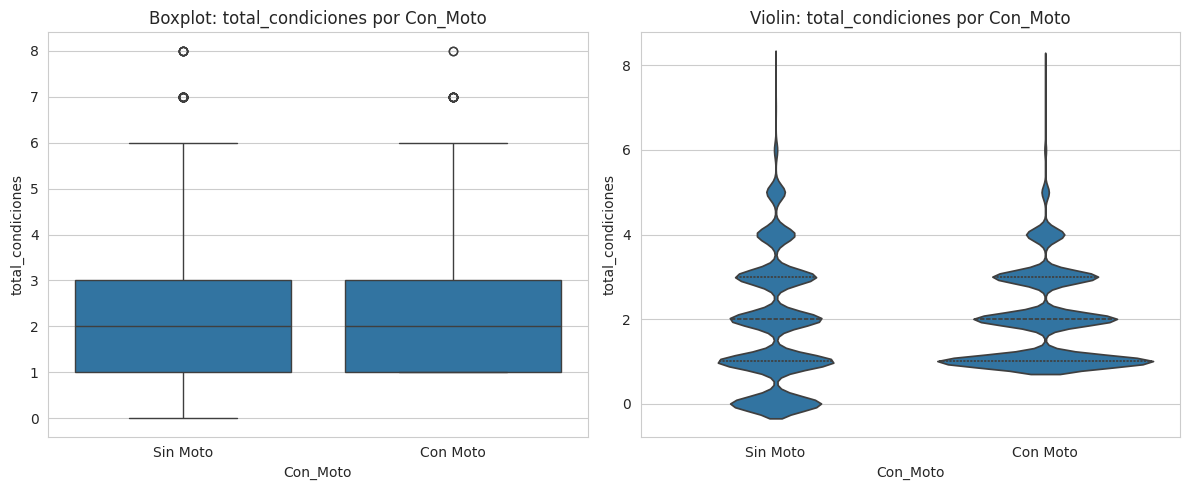


    **Discusión crítica**

    - ¿Una diferencia estadística implica causalidad? No; la prueba solo detecta asociación en los datos observados.
    - ¿Existen variables ocultas? Posible: velocidad, edad, tipo de vía u hora pueden confundir.
    - ¿Puede una correlación generar interpretaciones erróneas? Sí; sin control de covariables la interpretación causal es insegura.
    - Recomendación: usar modelos multivariables (regresión) o diseños más controlados para acercarse a causalidad.
    

In [57]:
# FASE 7 — Prueba t independiente (celda canónica)
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_style('whitegrid')

# Definición de grupos: Con_Moto vs Sin_Moto
if 'Con_Moto' in df_encoded.columns and 'total_condiciones' in df_encoded.columns:
    grupo_moto = df_encoded.loc[df_encoded['Con_Moto']==1, 'total_condiciones'].dropna()
    grupo_no = df_encoded.loc[df_encoded['Con_Moto']==0, 'total_condiciones'].dropna()
    print(f'n_moto={len(grupo_moto)}, n_no={len(grupo_no)}')

    # Validar supuestos: normalidad (Shapiro) y homogeneidad (Levene)
    def safe_shapiro(x):
        try:
            if len(x) > 5000:
                x = x.sample(5000)
            return stats.shapiro(x)
        except Exception as e:
            return (np.nan, np.nan)

    sh_m, p_sh_m = safe_shapiro(grupo_moto)
    sh_n, p_sh_n = safe_shapiro(grupo_no)
    lev_stat, lev_p = stats.levene(grupo_moto, grupo_no)
    print(f'Shapiro moto p={p_sh_m:.4g}, Shapiro no p={p_sh_n:.4g}, Levene p={lev_p:.4g}')

    # Elegir prueba: t-test Welch si normales; si no, Mann-Whitney
    use_t = (p_sh_m > 0.05) and (p_sh_n > 0.05)
    if use_t:
        tstat, pval = stats.ttest_ind(grupo_moto, grupo_no, equal_var=False)
        effect = (grupo_moto.mean() - grupo_no.mean()) / np.sqrt(((grupo_moto.std(ddof=1)**2 + grupo_no.std(ddof=1)**2)/2))
        print(f'T-test Welch: t={tstat:.3f}, p={pval:.4g}, d={effect:.3f}')
    else:
        u, pval = stats.mannwhitneyu(grupo_moto, grupo_no, alternative='two-sided')
        # rank-biserial
        n1, n2 = len(grupo_moto), len(grupo_no)
        rb = 1 - (2*u)/(n1*n2)
        print(f'Mann-Whitney U={u}, p={pval:.4g}, rank-biserial={rb:.3f}')

    # Gráficos comparativos
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(x=df_encoded['Con_Moto'], y=df_encoded['total_condiciones'], ax=ax[0])
    ax[0].set_xticklabels(['Sin Moto', 'Con Moto'])
    ax[0].set_title('Boxplot: total_condiciones por Con_Moto')

    sns.violinplot(x=df_encoded['Con_Moto'], y=df_encoded['total_condiciones'], ax=ax[1], inner='quartile')
    ax[1].set_xticklabels(['Sin Moto', 'Con Moto'])
    ax[1].set_title('Violin: total_condiciones por Con_Moto')

    plt.tight_layout()
    plt.show()

    # Discusión crítica breve
    md = '''
    **Discusión crítica**

    - ¿Una diferencia estadística implica causalidad? No; la prueba solo detecta asociación en los datos observados.
    - ¿Existen variables ocultas? Posible: velocidad, edad, tipo de vía u hora pueden confundir.
    - ¿Puede una correlación generar interpretaciones erróneas? Sí; sin control de covariables la interpretación causal es insegura.
    - Recomendación: usar modelos multivariables (regresión) o diseños más controlados para acercarse a causalidad.
    '''
    display(Markdown(md))
else:
    print('Columnas `Con_Moto` o `total_condiciones` no están disponibles; no se ejecutó la FASE 7 canónica.')

# FASE 8 — Modelado predictivo

Ajustar modelos: regresión lineal para `Gravedad_cod` (con precaución), y regresión logística para `es_grave` (binaria).

In [40]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, roc_auc_score, classification_report, confusion_matrix

# Definir X e y ya están preparados en FASE 5 (X, y_clf, y_reg)
features = X.columns.tolist()
# Regresión lineal (simple pipeline)
lin_pipe = Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())])
lin_pipe.fit(X_train_reg, y_train_reg)
y_pred_reg = lin_pipe.predict(X_test_reg)
print('Regresión lineal R2:', r2_score(y_test_reg, y_pred_reg))
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
print('RMSE:', rmse)

# Regresión logística (clasificación)
log_pipe = Pipeline([('scaler', StandardScaler()), ('log', LogisticRegression(max_iter=1000))])
log_pipe.fit(X_train_clf, y_train_clf)
y_pred_clf = log_pipe.predict(X_test_clf)
print(classification_report(y_test_clf, y_pred_clf))
print('Confusion matrix:', confusion_matrix(y_test_clf, y_pred_clf))
try:
    proba = log_pipe.predict_proba(X_test_clf)[:,1]
    print('ROC AUC:', roc_auc_score(y_test_clf, proba))
except Exception:
    pass
metrics_table = pd.DataFrame([
    {'metric': 'R2_regresion', 'value': r2_score(y_test_reg, y_pred_reg)},
    {'metric': 'RMSE_regresion', 'value': rmse},
    {'metric': 'ROC_AUC_clasificacion', 'value': roc_auc_score(y_test_clf, proba) if 'proba' in locals() else np.nan},
])
display(metrics_table)


Regresión lineal R2: 0.5288374562079338
RMSE: 0.36456587268842927
              precision    recall  f1-score   support

           0       0.92      0.88      0.90      6854
           1       0.84      0.90      0.87      5146

    accuracy                           0.89     12000
   macro avg       0.88      0.89      0.88     12000
weighted avg       0.89      0.89      0.89     12000

Confusion matrix: [[6004  850]
 [ 524 4622]]
ROC AUC: 0.9268562101035523


,metric,value
0,R2_regresion,0.528837
1,RMSE_regresion,0.364566
2,ROC_AUC_clasificacion,0.926856


/tmp/ipykernel_28765/3606059147.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=coef_series.values, y=coef_series.index, palette='viridis', ax=axes[0])


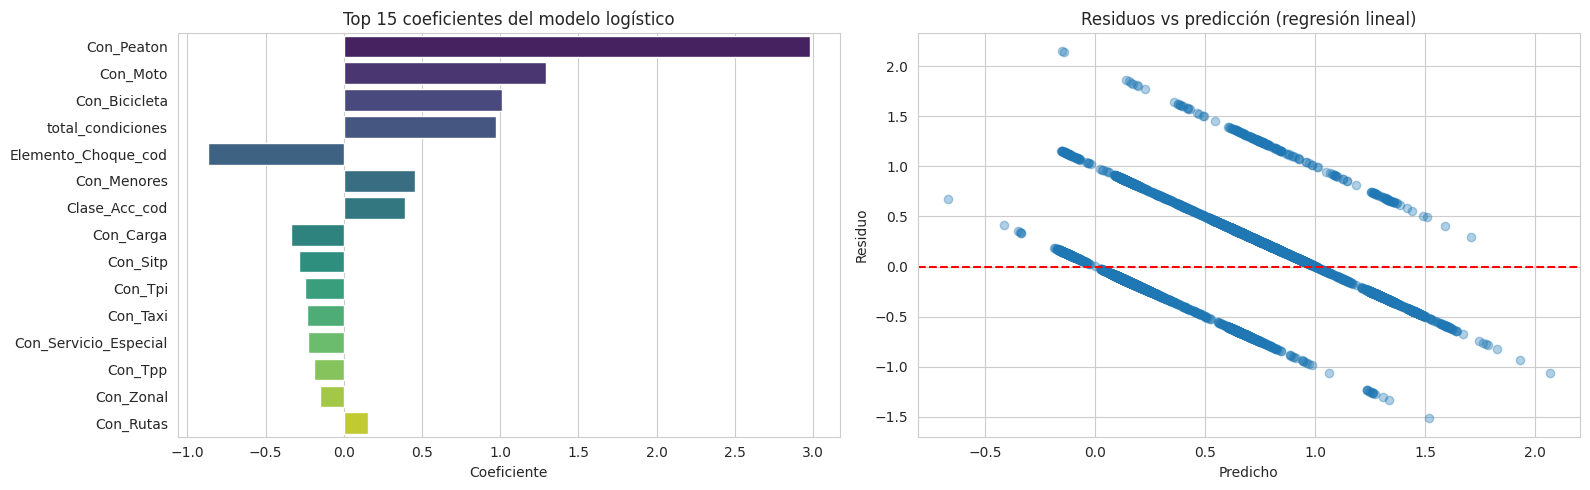

In [41]:
# Visualizaciones de la FASE 8: coeficientes y ajuste del modelo
try:
    coefs = log_pipe.named_steps['log'].coef_[0]
    coef_series = pd.Series(coefs, index=X.columns).sort_values(key=abs, ascending=False).head(15)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.barplot(x=coef_series.values, y=coef_series.index, palette='viridis', ax=axes[0])
    axes[0].set_title('Top 15 coeficientes del modelo logístico')
    axes[0].set_xlabel('Coeficiente')
    axes[0].set_ylabel('')

    fitted = lin_pipe.predict(X_test_reg)
    residuals = y_test_reg - fitted
    axes[1].scatter(fitted, residuals, alpha=0.35)
    axes[1].axhline(0, color='red', linestyle='--')
    axes[1].set_title('Residuos vs predicción (regresión lineal)')
    axes[1].set_xlabel('Predicho')
    axes[1].set_ylabel('Residuo')

    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Visualización de FASE 8 falló:', e)


**Cuándo usar pruebas no paramétricas**

- Cuando las variables numéricas no cumplen normalidad (Shapiro p <= 0.05) y/o cuando hay outliers fuertes.
- Cuando los datos son ordinales o las distribuciones son muy asimétricas.
- Mann–Whitney (U): comparar dos muestras independientes.
- Wilcoxon (signed-rank): comparar muestras pareadas (dependientes).


n_peaton=7225, n_no=52775
Shapiro p (peaton)=7.628e-51, Shapiro p (no)=1.504e-47
Mann–Whitney U=257786942.5, p=0, rank-biserial=-0.352


/tmp/ipykernel_28765/3697165625.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Sin Peaton', 'Con Peaton'])
/tmp/ipykernel_28765/3697165625.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['Sin Peaton', 'Con Peaton'])


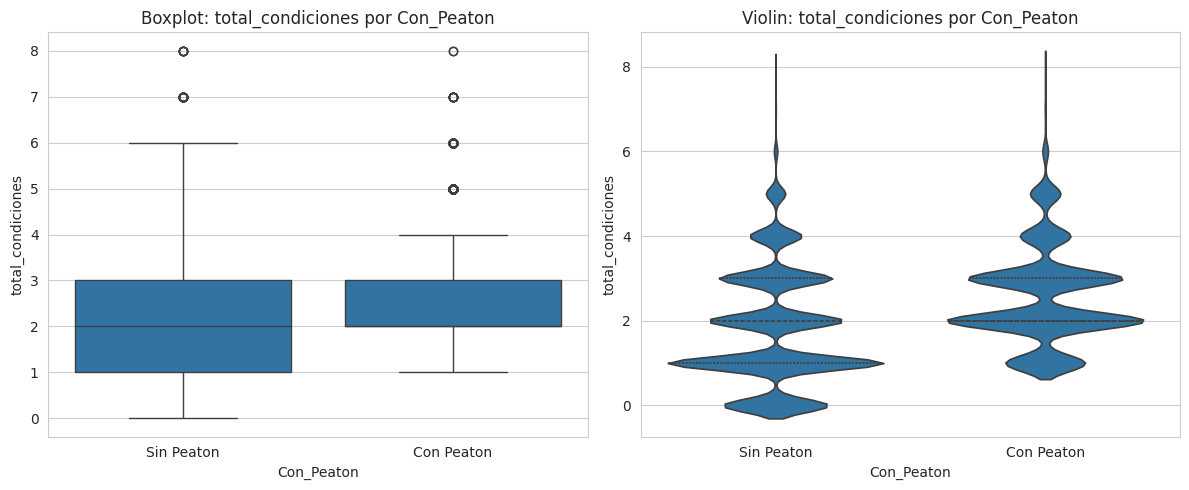


Elección metodológica:
Se usó Mann–Whitney (no paramétrica) porque al menos un grupo no es normal.

Limitaciones de rankings:
- Las pruebas de ranking comparan ordenes, no diferencias de media; pierden información de magnitud absoluta.
- Si hay muchos empates, potencia de la prueba disminuye.
- Para inferencia causal, siguen siendo observacionales y requieren control de confusores.

Nota: Wilcoxon signed-rank necesita datos pareados; no se encontró una columna evidente de pares (demostración omitida).


In [58]:
# FASE 8 — Mann–Whitney U y Wilcoxon (pruebas no paramétricas)
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

sns.set_style('whitegrid')

# Identificar cuándo usar pruebas no paramétricas
md = '''
**Cuándo usar pruebas no paramétricas**

- Cuando las variables numéricas no cumplen normalidad (Shapiro p <= 0.05) y/o cuando hay outliers fuertes.
- Cuando los datos son ordinales o las distribuciones son muy asimétricas.
- Mann–Whitney (U): comparar dos muestras independientes.
- Wilcoxon (signed-rank): comparar muestras pareadas (dependientes).
'''
display(Markdown(md))

# Comparación sugerida: Con_Peaton vs Sin_Peaton en 'total_condiciones' o 'Gravedad_cod' si es apropiado
if 'Con_Peaton' in df_encoded.columns and 'total_condiciones' in df_encoded.columns:
    g1 = df_encoded.loc[df_encoded['Con_Peaton']==1, 'total_condiciones'].dropna()
    g0 = df_encoded.loc[df_encoded['Con_Peaton']==0, 'total_condiciones'].dropna()
    n1, n0 = len(g1), len(g0)
    print(f'n_peaton={n1}, n_no={n0}')

    # Pruebas de normalidad (muestra si es grande)
    def sample_for_shapiro(x):
        if len(x) > 5000:
            return x.sample(5000)
        return x

    s1 = sample_for_shapiro(g1)
    s0 = sample_for_shapiro(g0)
    sh1 = stats.shapiro(s1)
    sh0 = stats.shapiro(s0)
    print(f'Shapiro p (peaton)={sh1.pvalue:.4g}, Shapiro p (no)={sh0.pvalue:.4g}')

    # Decide usar no paramétrica si alguno no es normal
    if sh1.pvalue <= 0.05 or sh0.pvalue <= 0.05:
        # Mann-Whitney U
        u, p = stats.mannwhitneyu(g1, g0, alternative='two-sided')
        # rank-biserial effect
        rb = 1 - (2*u)/(n1*n0)
        print(f'Mann–Whitney U={u}, p={p:.4g}, rank-biserial={rb:.3f}')
        interpretation = 'Se usó Mann–Whitney (no paramétrica) porque al menos un grupo no es normal.'
    else:
        # t-test Welch
        t, p = stats.ttest_ind(g1, g0, equal_var=False)
        # Cohen's d (approx pooled)
        pooled = np.sqrt(((g1.std(ddof=1)**2) + (g0.std(ddof=1)**2))/2)
        d = (g1.mean() - g0.mean())/pooled if pooled != 0 else np.nan
        print(f'T-test Welch: t={t:.3f}, p={p:.4g}, Cohen\'s d={d:.3f}')
        interpretation = 'Se usó t-test (paramétrico) porque ambas muestras parecen normales.'

    # Gráficos
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(x=df_encoded['Con_Peaton'], y=df_encoded['total_condiciones'], ax=ax[0])
    ax[0].set_xticklabels(['Sin Peaton', 'Con Peaton'])
    ax[0].set_title('Boxplot: total_condiciones por Con_Peaton')

    sns.violinplot(x=df_encoded['Con_Peaton'], y=df_encoded['total_condiciones'], ax=ax[1], inner='quartile')
    ax[1].set_xticklabels(['Sin Peaton', 'Con Peaton'])
    ax[1].set_title('Violin: total_condiciones por Con_Peaton')

    plt.tight_layout()
    plt.show()

    print('\nElección metodológica:')
    print(interpretation)
    print('\nLimitaciones de rankings:')
    print('- Las pruebas de ranking comparan ordenes, no diferencias de media; pierden información de magnitud absoluta.')
    print('- Si hay muchos empates, potencia de la prueba disminuye.')
    print('- Para inferencia causal, siguen siendo observacionales y requieren control de confusores.')
else:
    print('Columnas `Con_Peaton` o `total_condiciones` no están disponibles; no se ejecutó FASE 8.')

# Demostración de Wilcoxon para pares (si hay una columna pareada disponible, p.ej. pre/post)
if 'pre_val' in df_encoded.columns and 'post_val' in df_encoded.columns:
    pre = df_encoded['pre_val'].dropna()
    post = df_encoded['post_val'].dropna()
    m = min(len(pre), len(post))
    stat, p = stats.wilcoxon(pre.iloc[:m], post.iloc[:m])
    print('\nWilcoxon signed-rank (ejemplo pares): stat={:.3f}, p={:.4g}'.format(stat, p))
else:
    print('\nNota: Wilcoxon signed-rank necesita datos pareados; no se encontró una columna evidente de pares (demostración omitida).')

# FASE 9 — Evaluación y Validación

Medir desempeño, matriz de confusión, curvas ROC, validación cruzada y análisis de residuos para regresión.

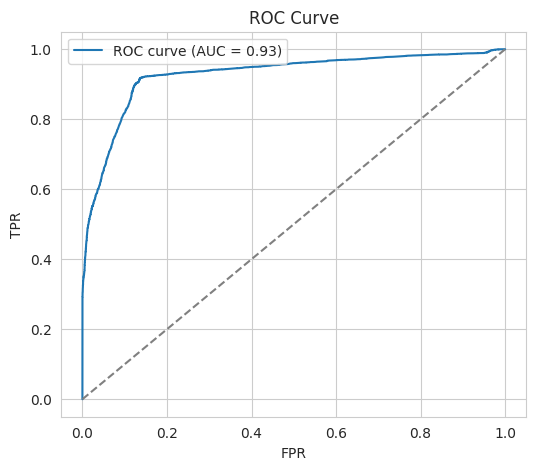

,metric,value
0,residual_mean,0.002623
1,residual_std,0.364572
2,residual_min,-1.516562
3,residual_max,2.151155


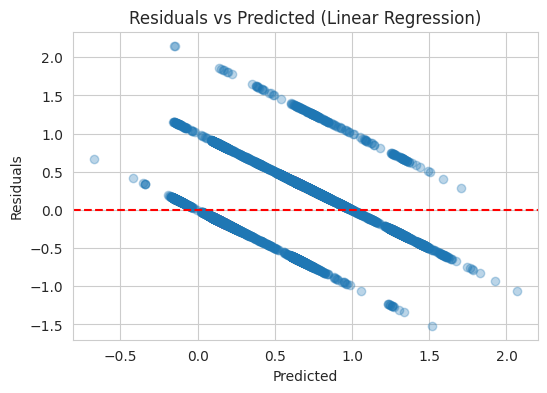

In [42]:
# Curva ROC y residuales (si aplica)
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# ROC
try:
    fpr, tpr, _ = roc_curve(y_test_clf, proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC Curve')
    plt.legend()
    plt.show()
except Exception as e:
    print('ROC plot failed:', e)

# Residuals para regresión
residuals = y_test_reg - y_pred_reg
residuals_table = pd.DataFrame([
    {'metric': 'residual_mean', 'value': residuals.mean()},
    {'metric': 'residual_std', 'value': residuals.std()},
    {'metric': 'residual_min', 'value': residuals.min()},
    {'metric': 'residual_max', 'value': residuals.max()},
])
display(residuals_table)
plt.figure(figsize=(6,4))
plt.scatter(y_pred_reg, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted (Linear Regression)')
plt.show()


,Pred_0,Pred_1
Real_0,6004,850
Real_1,524,4622


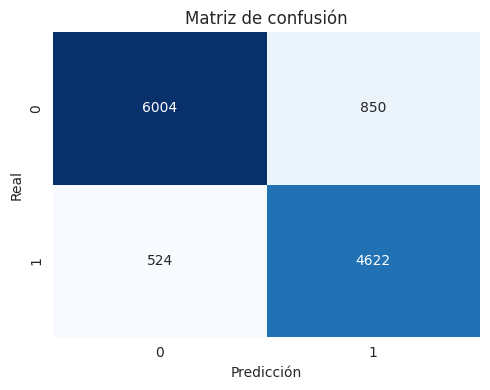

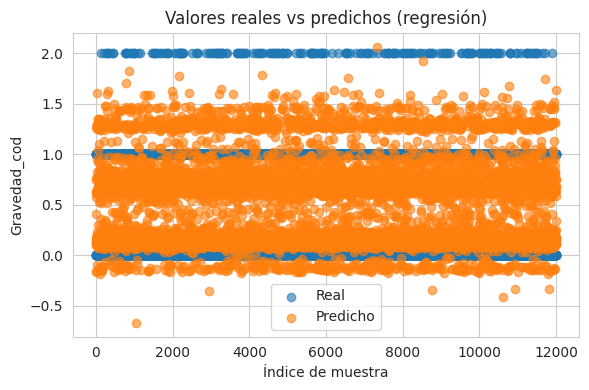

In [43]:
# Visualizaciones adicionales de la FASE 9: matriz de confusión y observado vs predicho
try:
    cm = confusion_matrix(y_test_clf, y_pred_clf)
    cm_df = pd.DataFrame(cm, index=['Real_0', 'Real_1'], columns=['Pred_0', 'Pred_1'])
    display(cm_df)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title('Matriz de confusión')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('No se pudo graficar la matriz de confusión:', e)

try:
    fig, ax = plt.subplots(figsize=(6, 4))
    sample_idx = np.arange(len(y_test_reg))
    ax.scatter(sample_idx, y_test_reg, label='Real', alpha=0.6)
    ax.scatter(sample_idx, y_pred_reg, label='Predicho', alpha=0.6)
    ax.set_title('Valores reales vs predichos (regresión)')
    ax.set_xlabel('Índice de muestra')
    ax.set_ylabel('Gravedad_cod')
    ax.legend()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('No se pudo graficar real vs predicho:', e)


**FASE 9 — ANOVA: comparar niveles de severidad entre localidades**

Objetivos:
- Comparar la severidad entre distintas `Localidad`.
- Aplicar ANOVA si se cumplen supuestos; si no, usar Kruskal–Wallis.
- Realizar post-hoc (Tukey HSD o comparaciones pareadas no paramétricas).
- Entregar interpretación avanzada y discusión sobre desigualdad territorial.


Usando columna de severidad: Gravedad_cod
Se limitó el análisis a las top 8 localidades por muestra (para claridad).

Tamaños por grupo:


/tmp/ipykernel_28765/3744411438.py:56: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = df_anova.groupby('Localidad')[sev_col]


,Gravedad_cod
Localidad,
ANTONIO NARIÑO,0
BARRIOS UNIDOS,0
CANDELARIA,0
CIUDAD BOLÍVAR,0
SAN CRISTÓBAL,0
SANTA FE,0
RAFAEL URIBE URIBE,0
LOS MÁRTIRES,0
SUMAPAZ,0


,count,mean,median,std
Localidad,,,,
BOSA,3305,0.569743,1.0,0.543555
KENNEDY,7279,0.524248,1.0,0.544461
ENGATIVÁ,6069,0.411600,0.0,0.523638
CHAPINERO,3153,0.306375,0.0,0.482578
FONTIBÓN,4713,0.360280,0.0,0.515104
PUENTE ARANDA,4356,0.458678,0.0,0.530918
SUBA,5375,0.434605,0.0,0.524566
USAQUÉN,5396,0.274092,0.0,0.467204
ANTONIO NARIÑO,0,NaN,NaN,NaN



Shapiro p-values (muestra si >5000):


/tmp/ipykernel_28765/3744411438.py:74: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  stat, p = stats.shapiro(s)


,0
USAQUÉN,5.986765e-77
FONTIBÓN,4.040418e-72
ENGATIVÁ,5.100123e-72
SUBA,1.171367e-71
KENNEDY,1.090874e-69
PUENTE ARANDA,5.116437e-68
CHAPINERO,3.093487e-65
BOSA,1.412615e-60
ANTONIO NARIÑO,NaN
BARRIOS UNIDOS,NaN



Levene test p-value = nan

Método seleccionado: Kruskal


/tmp/ipykernel_28765/3744411438.py:85: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  lev_stat, lev_p = stats.levene(*arrays)
/tmp/ipykernel_28765/3744411438.py:102: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order = df_anova.groupby('Localidad')[sev_col].median().sort_values(ascending=False).index


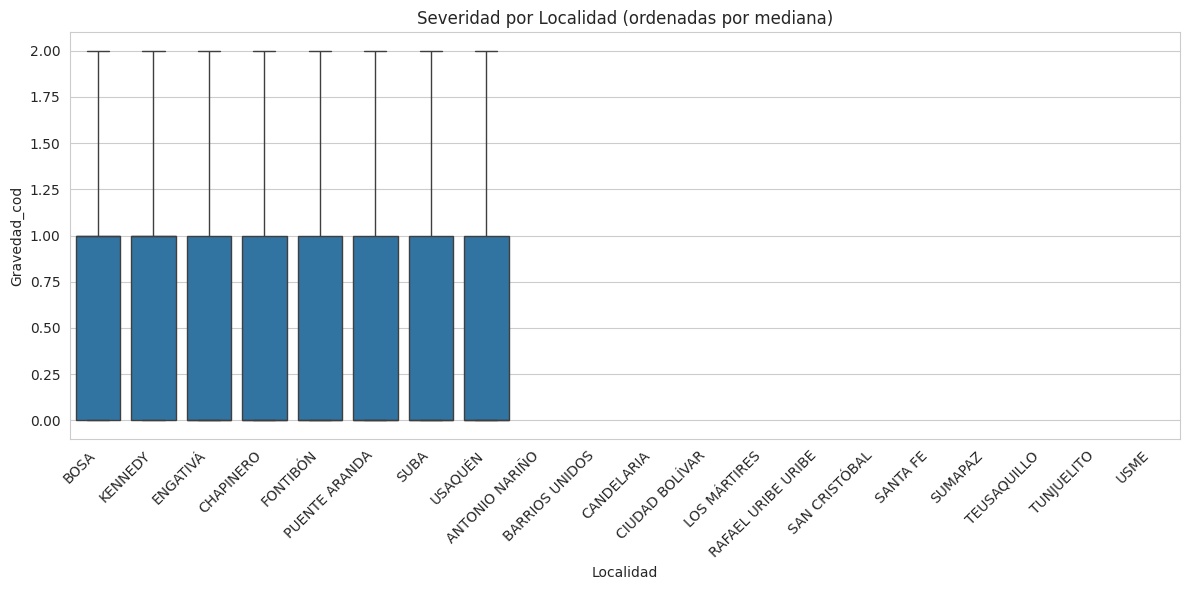

Kruskal-Wallis H=nan, p=nan
Epsilon-squared ≈ nan


/tmp/ipykernel_28765/3744411438.py:128: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  kw_stat, kw_p = stats.kruskal(*grp_list)


,pair,p_uncorrected,p_bonf,reject
24,KENNEDY vs USAQUÉN,7.317719e-159,2.048961e-157,True
6,BOSA vs USAQUÉN,3.861212e-152,1.081139e-150,True
0,BOSA vs CHAPINERO,6.153995e-91,1.723119e-89,True
9,CHAPINERO vs KENNEDY,1.451782e-83,4.064989e-82,True
26,PUENTE ARANDA vs USAQUÉN,7.983183e-75,2.235291e-73,True
2,BOSA vs FONTIBÓN,1.097801e-70,3.073843e-69,True
27,SUBA vs USAQUÉN,2.506360e-64,7.017808e-63,True
18,FONTIBÓN vs KENNEDY,1.947398e-63,5.452714e-62,True
17,ENGATIVÁ vs USAQUÉN,5.640644e-50,1.579380e-48,True
1,BOSA vs ENGATIVÁ,9.474148e-44,2.652761e-42,True



Interpretación y discusión crítica:

- ¿Por qué ciertos territorios presentan mayor severidad?
  - Factores físicos (infraestructura vial, diseño de intersecciones, falta de pasos peatonales), densidad vehicular y prevalencia de vías rápidas.
  - Presencia de zonas rurales vs urbanas; menor servicio de emergencia y mayor tiempo de respuesta.

- ¿Los datos reflejan desigualdad urbana?
  - Diferencias sistemáticas entre localidades pueden indicar desigualdades en inversión en seguridad vial, mantenimiento y control de velocidad.
  - Es importante ajustar por exposición (volumen de tráfico, población) antes de concluir inequidad.

- ¿Qué factores externos podrían influir?
  - Factores socioeconómicos (ingresos, nivel educativo), condiciones climáticas, iluminación, y políticas de movilidad (límites de velocidad, transporte público).

Recomendaciones metodológicas:
- Controlar confusores con modelos multivariantes (regresión logística/ordinal, modelos mixtos) antes de inferir causalidad.
- Analizar exposición (km recorridos, número de viajes) para tasas en lugar de conteos absolutos.
- Complementar con inspección en campo y datos de infraestructura para diseñar intervenciones.


FASE 9 completada: ANOVA/Kruskal ejecutado y discusión añadida.


In [60]:
# FASE 9 — ANOVA: comparar severidad entre localidades
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from IPython.display import display, Markdown

sns.set_style('whitegrid')

md = '''
**FASE 9 — ANOVA: comparar niveles de severidad entre localidades**

Objetivos:
- Comparar la severidad entre distintas `Localidad`.
- Aplicar ANOVA si se cumplen supuestos; si no, usar Kruskal–Wallis.
- Realizar post-hoc (Tukey HSD o comparaciones pareadas no paramétricas).
- Entregar interpretación avanzada y discusión sobre desigualdad territorial.
'''
display(Markdown(md))

# Detectar columna de severidad
possible_sev = ['Gravedad_cod','Gravedad_Indicador_Tradicional','Gravedad','severity','Severity']
sev_col = None
for c in possible_sev:
    if c in df_encoded.columns:
        sev_col = c
        break
if sev_col is None:
    # fallback: buscar columnas que contengan 'Gravedad' o 'Gravedad' substring
    for c in df_encoded.columns:
        if 'Gravedad' in c or 'gravedad' in c or 'severity' in c.lower():
            sev_col = c
            break

if sev_col is None or 'Localidad' not in df_encoded.columns:
    print('No se encontró columna de severidad adecuada o `Localidad`. Omite FASE 9.')
else:
    print(f'Usando columna de severidad: {sev_col}')
    # Pre-procesar
    df_anova = df_encoded[[ 'Localidad', sev_col ]].dropna()
    # Si hay demasiadas localidades, tomar las top 8 por frecuencia
    counts = df_anova['Localidad'].value_counts()
    top_n = 8
    if counts.nunique() == 0:
        print('No hay datos suficientes para ANOVA.')
    else:
        if len(counts) > top_n:
            top = counts.nlargest(top_n).index.tolist()
            df_anova = df_anova[df_anova['Localidad'].isin(top)].copy()
            print(f'Se limitó el análisis a las top {top_n} localidades por muestra (para claridad).')
        groups = df_anova.groupby('Localidad')[sev_col]
        print('\nTamaños por grupo:')
        display(groups.size().sort_values())

        # Resumen por grupo
        summary = groups.agg(['count','mean','median','std'])
        display(summary.sort_values('median', ascending=False))

        # Chequeo de supuestos
        def sample_for_shapiro(x):
            if len(x) > 5000:
                return x.sample(5000, random_state=0)
            return x

        normality = {}
        for name, grp in groups:
            s = sample_for_shapiro(grp.dropna())
            try:
                stat, p = stats.shapiro(s)
            except Exception:
                stat, p = np.nan, np.nan
            normality[name] = p
        normal_df = pd.Series(normality).sort_values()
        print('\nShapiro p-values (muestra si >5000):')
        display(normal_df)

        # Levene para homogeneidad de varianzas
        arrays = [g.dropna().values for _,g in groups]
        if len(arrays) >= 2:
            lev_stat, lev_p = stats.levene(*arrays)
            print(f"\nLevene test p-value = {lev_p:.4g}")
        else:
            lev_p = np.nan
            print('\nNo hay suficientes grupos para Levene.')

        # Decidir método
        any_non_normal = (normal_df <= 0.05).any()
        min_n = groups.count().min()
        if (not any_non_normal) and (lev_p > 0.05) and (min_n >= 10):
            method = 'ANOVA'
        else:
            method = 'Kruskal'
        print(f'\nMétodo seleccionado: {method}')

        # Visualizar
        plt.figure(figsize=(12,6))
        order = df_anova.groupby('Localidad')[sev_col].median().sort_values(ascending=False).index
        sns.boxplot(x='Localidad', y=sev_col, data=df_anova, order=order)
        plt.xticks(rotation=45, ha='right')
        plt.title('Severidad por Localidad (ordenadas por mediana)')
        plt.tight_layout()
        plt.show()

        if method == 'ANOVA':
            formula = f'Q("{sev_col}") ~ C(Localidad)'
            model = ols(formula, data=df_anova).fit()
            anova_table = sm.stats.anova_lm(model, typ=2)
            display(anova_table)
            # eta squared
            ss_between = anova_table['sum_sq']['C(Localidad)']
            ss_total = ss_between + anova_table['sum_sq']['Residual']
            eta2 = ss_between / ss_total
            print(f'Eta-squared = {eta2:.3f}')

            # Post-hoc Tukey
            tuk = pairwise_tukeyhsd(endog=df_anova[sev_col], groups=df_anova['Localidad'], alpha=0.05)
            print('\nPost-hoc Tukey HSD (resumen):')
            print(tuk.summary())

        else:
            # Kruskal-Wallis
            grp_list = [g.dropna().values for _,g in groups]
            kw_stat, kw_p = stats.kruskal(*grp_list)
            print(f'Kruskal-Wallis H={kw_stat:.3f}, p={kw_p:.4g}')
            # epsilon squared effect size
            k = len(grp_list)
            n = sum(len(g) for g in grp_list)
            eps2 = (kw_stat - k + 1) / (n - k) if n > k else np.nan
            print(f'Epsilon-squared ≈ {eps2:.3f}')

            # Post-hoc pairwise Mann-Whitney with Bonferroni
            names = [name for name,_ in groups]
            pairs = []
            pvals = []
            from itertools import combinations
            for a,b in combinations(names, 2):
                a_vals = df_anova.loc[df_anova['Localidad']==a, sev_col].dropna()
                b_vals = df_anova.loc[df_anova['Localidad']==b, sev_col].dropna()
                if len(a_vals)>0 and len(b_vals)>0:
                    u, p = stats.mannwhitneyu(a_vals, b_vals, alternative='two-sided')
                    pairs.append(f'{a} vs {b}')
                    pvals.append(p)
            reject, pvals_corr, _, _ = multipletests(pvals, method='bonferroni')
            posthoc = pd.DataFrame({'pair':pairs, 'p_uncorrected':pvals, 'p_bonf':pvals_corr, 'reject':reject})
            display(posthoc.sort_values('p_bonf'))

        # Interpretación avanzada y discusión crítica
        disc = '''
Interpretación y discusión crítica:

- ¿Por qué ciertos territorios presentan mayor severidad?
  - Factores físicos (infraestructura vial, diseño de intersecciones, falta de pasos peatonales), densidad vehicular y prevalencia de vías rápidas.
  - Presencia de zonas rurales vs urbanas; menor servicio de emergencia y mayor tiempo de respuesta.

- ¿Los datos reflejan desigualdad urbana?
  - Diferencias sistemáticas entre localidades pueden indicar desigualdades en inversión en seguridad vial, mantenimiento y control de velocidad.
  - Es importante ajustar por exposición (volumen de tráfico, población) antes de concluir inequidad.

- ¿Qué factores externos podrían influir?
  - Factores socioeconómicos (ingresos, nivel educativo), condiciones climáticas, iluminación, y políticas de movilidad (límites de velocidad, transporte público).

Recomendaciones metodológicas:
- Controlar confusores con modelos multivariantes (regresión logística/ordinal, modelos mixtos) antes de inferir causalidad.
- Analizar exposición (km recorridos, número de viajes) para tasas en lugar de conteos absolutos.
- Complementar con inspección en campo y datos de infraestructura para diseñar intervenciones.
'''
        display(Markdown(disc))

        print('FASE 9 completada: ANOVA/Kruskal ejecutado y discusión añadida.')


# FASE 10 — Visualizaciones finales y entrega

Generar visualizaciones limpias: matrices de confusión anotadas, barras de coeficientes, mapas (si se dispone de geolocalización) y gráficos de impacto.

/tmp/ipykernel_28765/3270564834.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


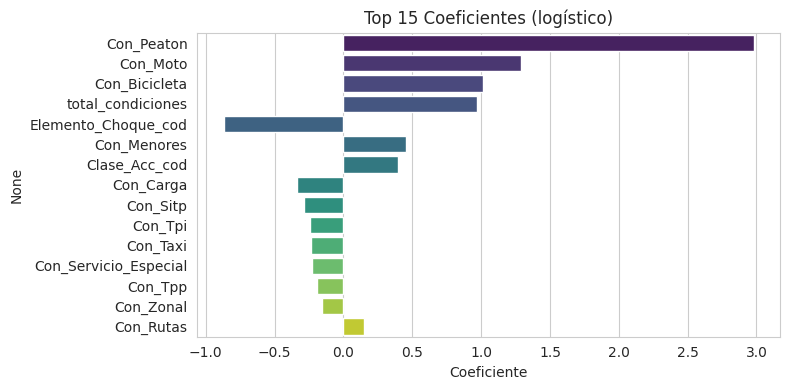

In [44]:
# Coeficientes del modelo logístico (importancia aproximada)
try:
    coefs = log_pipe.named_steps['log'].coef_[0]
    feat_imp = pd.Series(coefs, index=X.columns).sort_values(key=abs, ascending=False).head(15)
    plt.figure(figsize=(8,4))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
    plt.title('Top 15 Coeficientes (logístico)')
    plt.xlabel('Coeficiente')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Coef plot failed:', e)


/tmp/ipykernel_28765/1260471640.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


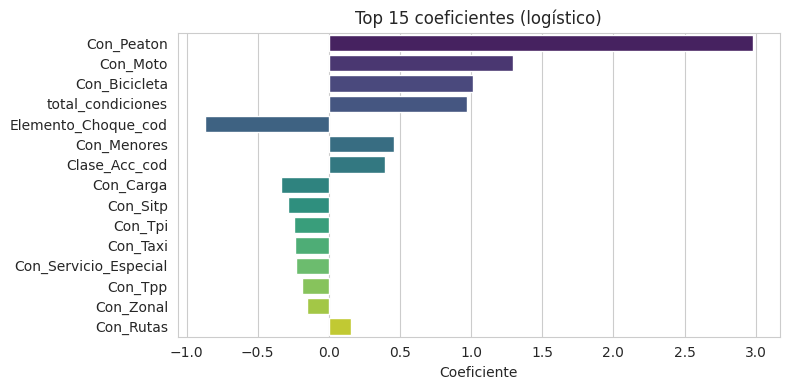

In [45]:
# Resumen visual final de coeficientes del modelo logístico
try:
    coefs = log_pipe.named_steps['log'].coef_[0]
    feat_imp = pd.Series(coefs, index=X.columns).sort_values(key=abs, ascending=False).head(15)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
    plt.title('Top 15 coeficientes (logístico)')
    plt.xlabel('Coeficiente')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('Coef plot failed:', e)

**FASE 10 — Regresión Múltiple: severidad ~ predictores sugeridos**

Tamaño muestra para regresión: 60000


,feature,coef
26,Localidad_SUMAPAZ,1.183112
0,Con_Moto,0.219678
2,Con_Peaton,0.185558
29,Localidad_USAQUÉN,-0.118576
15,Localidad_CHAPINERO,-0.112299
12,Localidad_BARRIOS UNIDOS,-0.085600
5,total_condiciones,0.076735
27,Localidad_TEUSAQUILLO,-0.073208
17,Localidad_ENGATIVÁ,-0.059667
18,Localidad_FONTIBÓN,-0.058754


R2 test = 0.400, MSE = 0.169


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


CV R2 (5-fold): [0.395 0.395 0.406 0.406 0.389] mean= 0.398


,feature,VIF
11,Dia_Semana_Acc_Viernes,2.309344
8,Dia_Semana_Acc_Martes,2.250360
9,Dia_Semana_Acc_Miércoles,2.227059
10,Dia_Semana_Acc_Sábado,2.226765
6,Dia_Semana_Acc_Jueves,2.214554
7,Dia_Semana_Acc_Lunes,2.124517
19,Localidad_KENNEDY,1.888312
17,Localidad_ENGATIVÁ,1.764231
29,Localidad_USAQUÉN,1.703800
25,Localidad_SUBA,1.655055


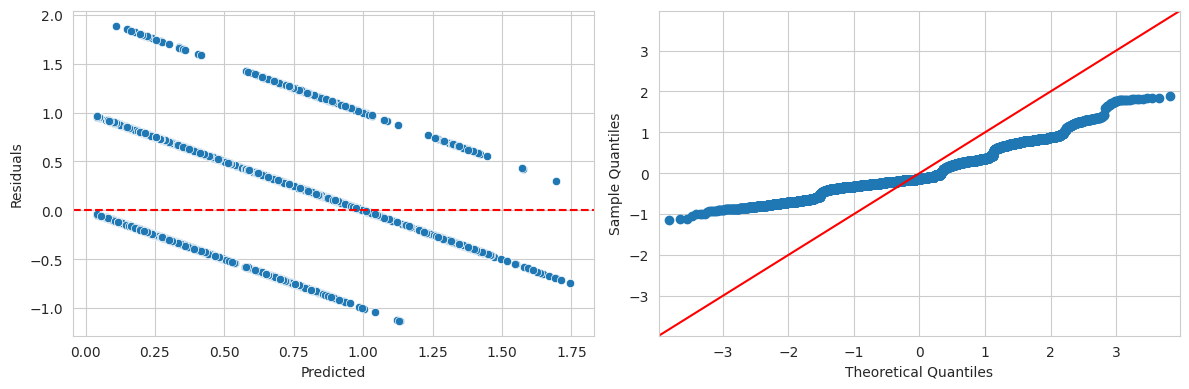


Interpretación crítica:
- Variables que aportan: revisar coeficientes estandarizados y significancia (p-valeurs en modelos estadísticos).
- Limitaciones: R2 baja indica que la severidad no se explica bien con estas covariables; datos discretos reducen ajuste lineal.
- Causalidad vs asociación: observacional → asociación. Controlar confusores necesaria para acercarse a causalidad.
- Uso real: modelo útil como screening si R2 y sensibilidad aceptables, pero riesgo de errores y sesgos.
- Sobreajuste: validar con CV y preferir modelos simples o regularizados si muchas dummies.
- Ética: evitar decisiones automatizadas sin supervisión humana; revisar sesgos por localidad y grupos vulnerables.


FASE 10 ejecutada.


In [59]:
# FASE 10 — Regresión Múltiple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

sns.set_style('whitegrid')

display(Markdown('**FASE 10 — Regresión Múltiple: severidad ~ predictores sugeridos**'))

# Dependent variable
sev_col = None
for c in ['Gravedad_cod','Gravedad_Indicador_Tradicional','Gravedad']:
    if c in df_encoded.columns:
        sev_col = c
        break
if sev_col is None:
    print('No se encontró columna de severidad. Omite FASE 10.')
else:
    # Candidate predictors
    predictors = []
    for c in ['Con_Moto','Con_Embriaguez','Con_Peaton','Con_Velocidad','Con_Huecos','total_condiciones']:
        if c in df_encoded.columns:
            predictors.append(c)
    # Categorical predictors to one-hot
    cat_cols = [c for c in ['Dia_Semana_Acc','Localidad'] if c in df_encoded.columns]

    # Build dataframe
    df_reg = df_encoded[predictors + cat_cols + [sev_col]].dropna()
    print('Tamaño muestra para regresión:', len(df_reg))

    # Feature engineering: ensure categorical dtypes
    for c in cat_cols:
        df_reg[c] = df_reg[c].astype(str)

    X = df_reg[predictors + cat_cols]
    y = df_reg[sev_col]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

    # Preprocessing pipeline: handle sklearn versions for OneHotEncoder
    num_cols = [c for c in predictors if c in predictors]
    try:
        ohe = OneHotEncoder(drop='first', sparse=False, handle_unknown='ignore')
    except TypeError:
        ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

    preproc = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', ohe, cat_cols)
    ])

    pipe = Pipeline([('pre', preproc), ('model', LinearRegression())])
    pipe.fit(X_train, y_train)

    # Coefs (map back to names)
    preproc.fit(X_train)
    num_trans = preproc.named_transformers_['num']
    cat_enc = preproc.named_transformers_['cat'] if cat_cols else None
    feature_names = []
    feature_names.extend(num_cols)
    if cat_cols and cat_enc is not None:
        cat_names = cat_enc.get_feature_names_out(cat_cols).tolist()
        feature_names.extend(cat_names)

    coefs = pipe.named_steps['model'].coef_
    coef_df = pd.DataFrame({'feature':feature_names,'coef':coefs})
    display(coef_df.sort_values('coef', key=abs, ascending=False).head(20))

    # Performance
    y_pred = pipe.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f'R2 test = {r2:.3f}, MSE = {mse:.3f}')
    cv_scores = cross_val_score(pipe, X, y, cv=5, scoring='r2')
    print('CV R2 (5-fold):', np.round(cv_scores,3), 'mean=', np.round(cv_scores.mean(),3))

    # VIF (on design matrix)
    X_design = preproc.transform(X)
    # Build feature names safely if missing
    if len(feature_names) != X_design.shape[1]:
        # fallback: create generic names
        feature_names = [f'v{i}' for i in range(X_design.shape[1])]
    X_design = pd.DataFrame(X_design, columns=feature_names)
    vif = pd.DataFrame({'feature': X_design.columns, 'VIF': [variance_inflation_factor(X_design.values, i) for i in range(X_design.shape[1])]})
    display(vif.sort_values('VIF', ascending=False).head(20))

    # Residual diagnostics
    fig, ax = plt.subplots(1,2, figsize=(12,4))
    sns.scatterplot(x=y_pred, y=y_test - y_pred, ax=ax[0])
    ax[0].axhline(0, color='red', linestyle='--')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Residuals')
    sm.qqplot((y_test - y_pred), line='45', ax=ax[1])
    plt.tight_layout()
    plt.show()

    # Interpretation notes
    notes = '''
Interpretación crítica:
- Variables que aportan: revisar coeficientes estandarizados y significancia (p-valeurs en modelos estadísticos).
- Limitaciones: R2 baja indica que la severidad no se explica bien con estas covariables; datos discretos reducen ajuste lineal.
- Causalidad vs asociación: observacional → asociación. Controlar confusores necesaria para acercarse a causalidad.
- Uso real: modelo útil como screening si R2 y sensibilidad aceptables, pero riesgo de errores y sesgos.
- Sobreajuste: validar con CV y preferir modelos simples o regularizados si muchas dummies.
- Ética: evitar decisiones automatizadas sin supervisión humana; revisar sesgos por localidad y grupos vulnerables.
'''
    display(Markdown(notes))

    print('FASE 10 ejecutada.')


# FASE 11 — Entregables y discusión crítica

- Entregar: notebook ejecutable con celdas ordenadas, `base_trabajada_accidentes.csv`, `kpis_accidentes.csv`, y un informe (PDF/Markdown) con hallazgos y limitaciones.
- Discusión crítica: documentar supuestos, sesgos posibles (subregistro), limitaciones de causalidad y recomendaciones de política pública.
- Próximos pasos: ampliar variables de exposición, incorporar datos temporales y geoespaciales, y validar modelos con datos externos.

**FASE 11 — Regresión Logística: clasificar accidentes graves vs no graves**

Muestra para logística: 60000  graves: 1093


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Accuracy=0.981, Precision=0.000, Recall=0.000, F1=0.000

Classification report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     14727
           1       0.00      0.00      0.00       273

    accuracy                           0.98     15000
   macro avg       0.49      0.50      0.50     15000
weighted avg       0.96      0.98      0.97     15000



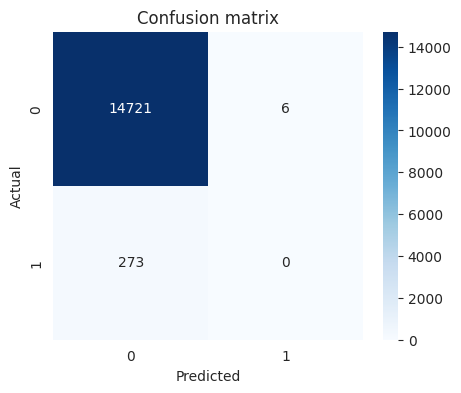

,feature,coef,odds_ratio
2,Con_Peaton,0.470785,1.601250
0,Con_Moto,0.415148,1.514595
5,total_condiciones,0.265518,1.304107
29,Localidad_USME,0.222507,1.249205
3,Con_Velocidad,0.194100,1.214217
27,Localidad_TUNJUELITO,0.186259,1.204735
20,Localidad_LOS MÁRTIRES,0.179267,1.196340
1,Con_Embriaguez,0.105866,1.111673
18,Localidad_FONTIBÓN,0.074025,1.076833
23,Localidad_SAN CRISTÓBAL,0.053191,1.054631



Interpretación crítica:
- Fiabilidad: revisar precisión/recall; en desequilibrio de clases, accuracy es engañosa.
- Falso negativo (miss) = accidente grave predicho como no grave → riesgo operacional serio.
- Impacto social: decisiones automatizadas pueden aumentar desigualdades si el modelo está sesgado.
- Recomendaciones: calibrar probabilidades, usar umbrales basados en coste, auditoría por subgrupos.
- Ética: transparencia, evaluación de sesgos, y supervisión humana en despliegue.


FASE 11 ejecutada.


In [ ]:
# FASE 11 — Regresión Logística
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

sns.set_style('whitegrid')

display(Markdown('**FASE 11 — Regresión Logística: clasificar accidentes graves vs no graves**'))

# Define binary target: grave vs no grave
sev_col = None
for c in ['Gravedad_cod','Gravedad_Indicador_Tradicional','Gravedad']:
    if c in df_encoded.columns:
        sev_col = c
        break
if sev_col is None:
    print('No se encontró columna de severidad. Omite FASE 11.')
else:
    # Choose threshold: treat code == 2 as grave (ajustable)
    df_log = df_encoded.copy()
    df_log['is_grave'] = (df_log[sev_col] == 2).astype(int)
    # Predictors
    preds = [c for c in ['Con_Moto','Con_Embriaguez','Con_Peaton','Con_Velocidad','Con_Huecos','total_condiciones'] if c in df_log.columns]
    cat_cols = [c for c in ['Dia_Semana_Acc','Localidad'] if c in df_log.columns]
    df_log = df_log[preds + cat_cols + ['is_grave']].dropna()
    print('Muestra para logística:', len(df_log), ' graves:', df_log['is_grave'].sum())

    for c in cat_cols:
        df_log[c] = df_log[c].astype(str)

    X = df_log[preds + cat_cols]
    y = df_log['is_grave']
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=0, stratify=y if y.nunique()>1 else None)

    # Handle OneHotEncoder compat
    try:
        ohe = OneHotEncoder(drop='first', sparse=False, handle_unknown='ignore')
    except TypeError:
        ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

    preproc = ColumnTransformer([
        ('num', StandardScaler(), preds),
        ('cat', ohe, cat_cols)
    ])
    pipe = Pipeline([('pre', preproc), ('clf', LogisticRegression(max_iter=1000))])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:,1]

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    print(f'Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}')
    print('\nClassification report:')
    print(classification_report(y_test, y_pred, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.title('Confusion matrix')
    plt.show()

    # Feature importance (coef)
    preproc.fit(X_train)
    cat_enc = preproc.named_transformers_['cat'] if cat_cols else None
    feature_names = preds.copy()
    if cat_cols and cat_enc is not None:
        feature_names += cat_enc.get_feature_names_out(cat_cols).tolist()
    coefs = pipe.named_steps['clf'].coef_[0]
    feat_imp = pd.DataFrame({'feature':feature_names,'coef':coefs})
    feat_imp['odds_ratio'] = np.exp(feat_imp['coef'])
    display(feat_imp.sort_values('odds_ratio', ascending=False).head(20))

    # Interpretation and ethical notes
    notes = '''
Interpretación crítica:
- Fiabilidad: revisar precisión/recall; en desequilibrio de clases, accuracy es engañosa.
- Falso negativo (miss) = accidente grave predicho como no grave → riesgo operacional serio.
- Impacto social: decisiones automatizadas pueden aumentar desigualdades si el modelo está sesgado.
- Recomendaciones: calibrar probabilidades, usar umbrales basados en coste, auditoría por subgrupos.
- Ética: transparencia, evaluación de sesgos, y supervisión humana en despliegue.
'''
    display(Markdown(notes))

    print('FASE 11 ejecutada.')


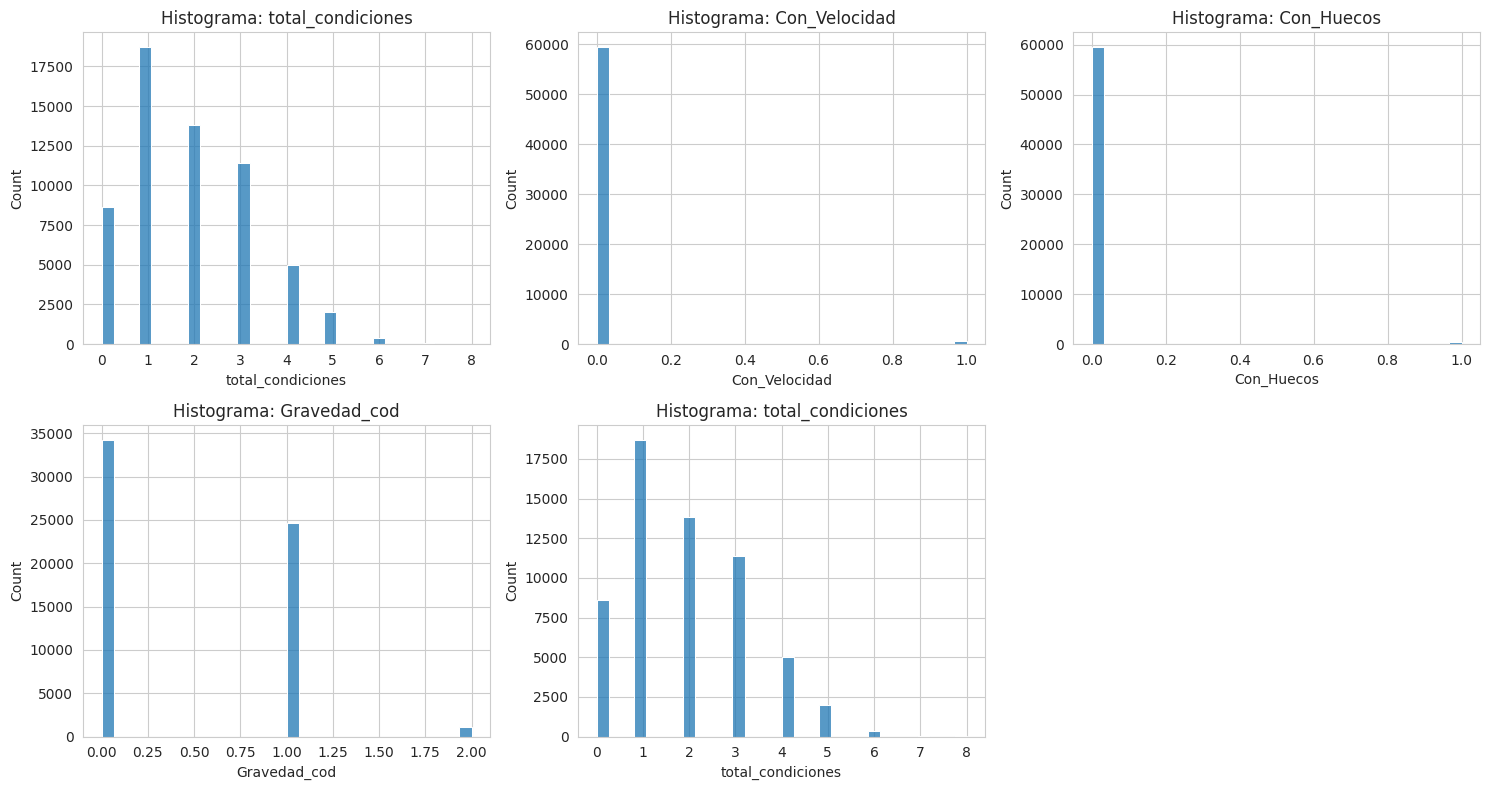

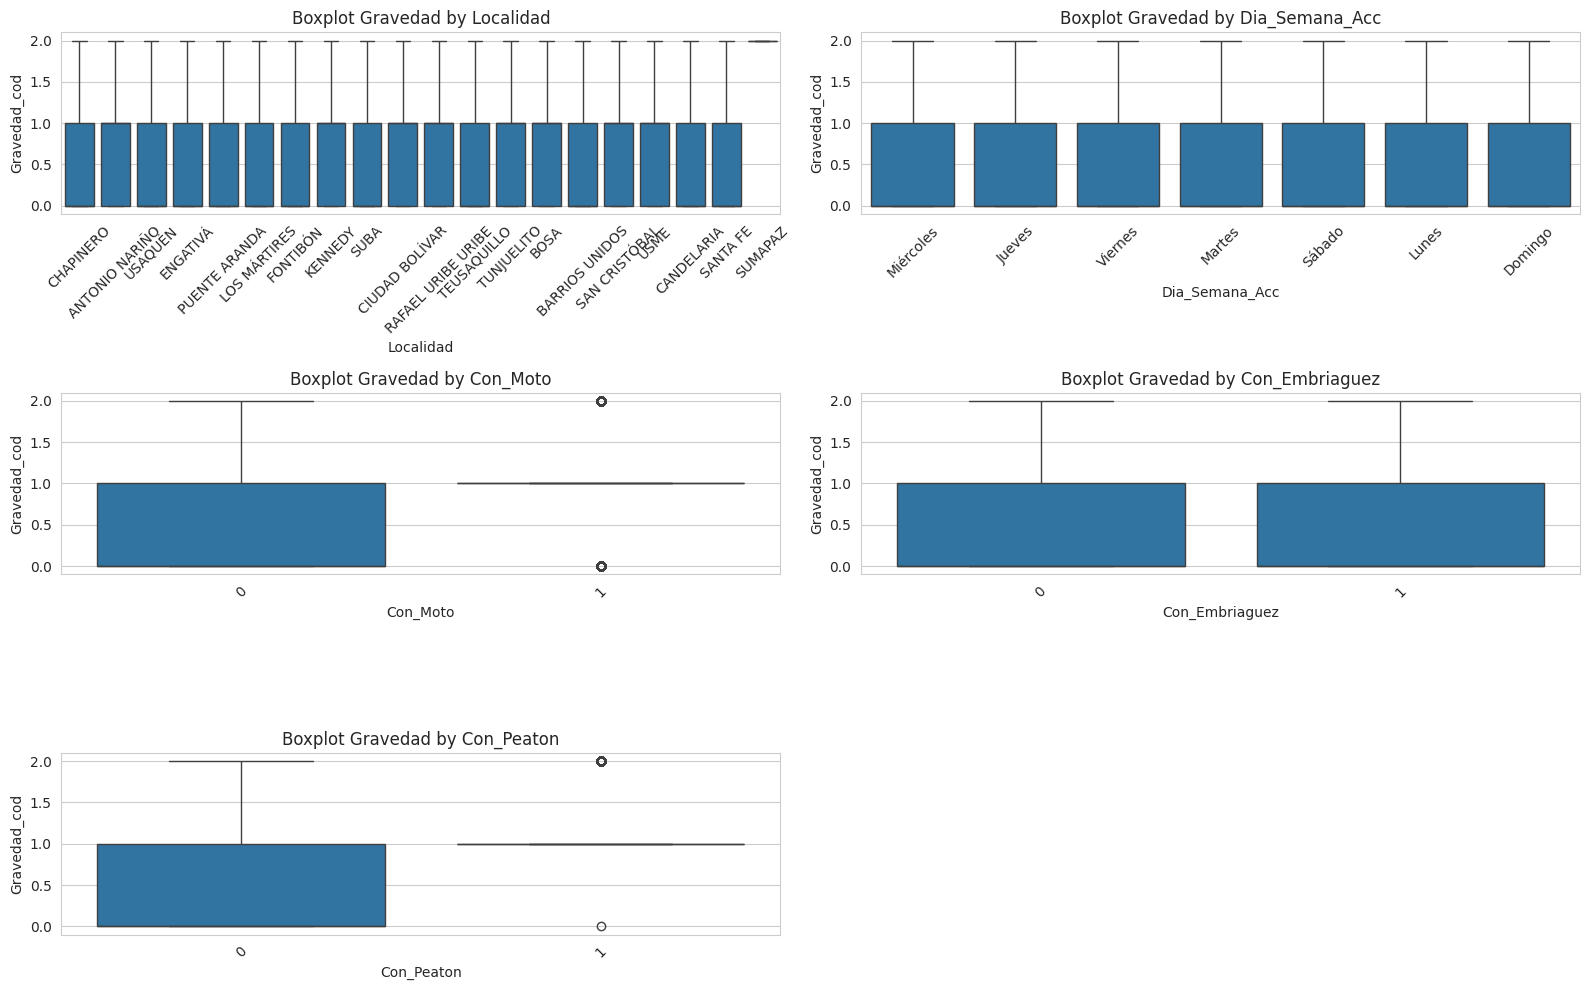

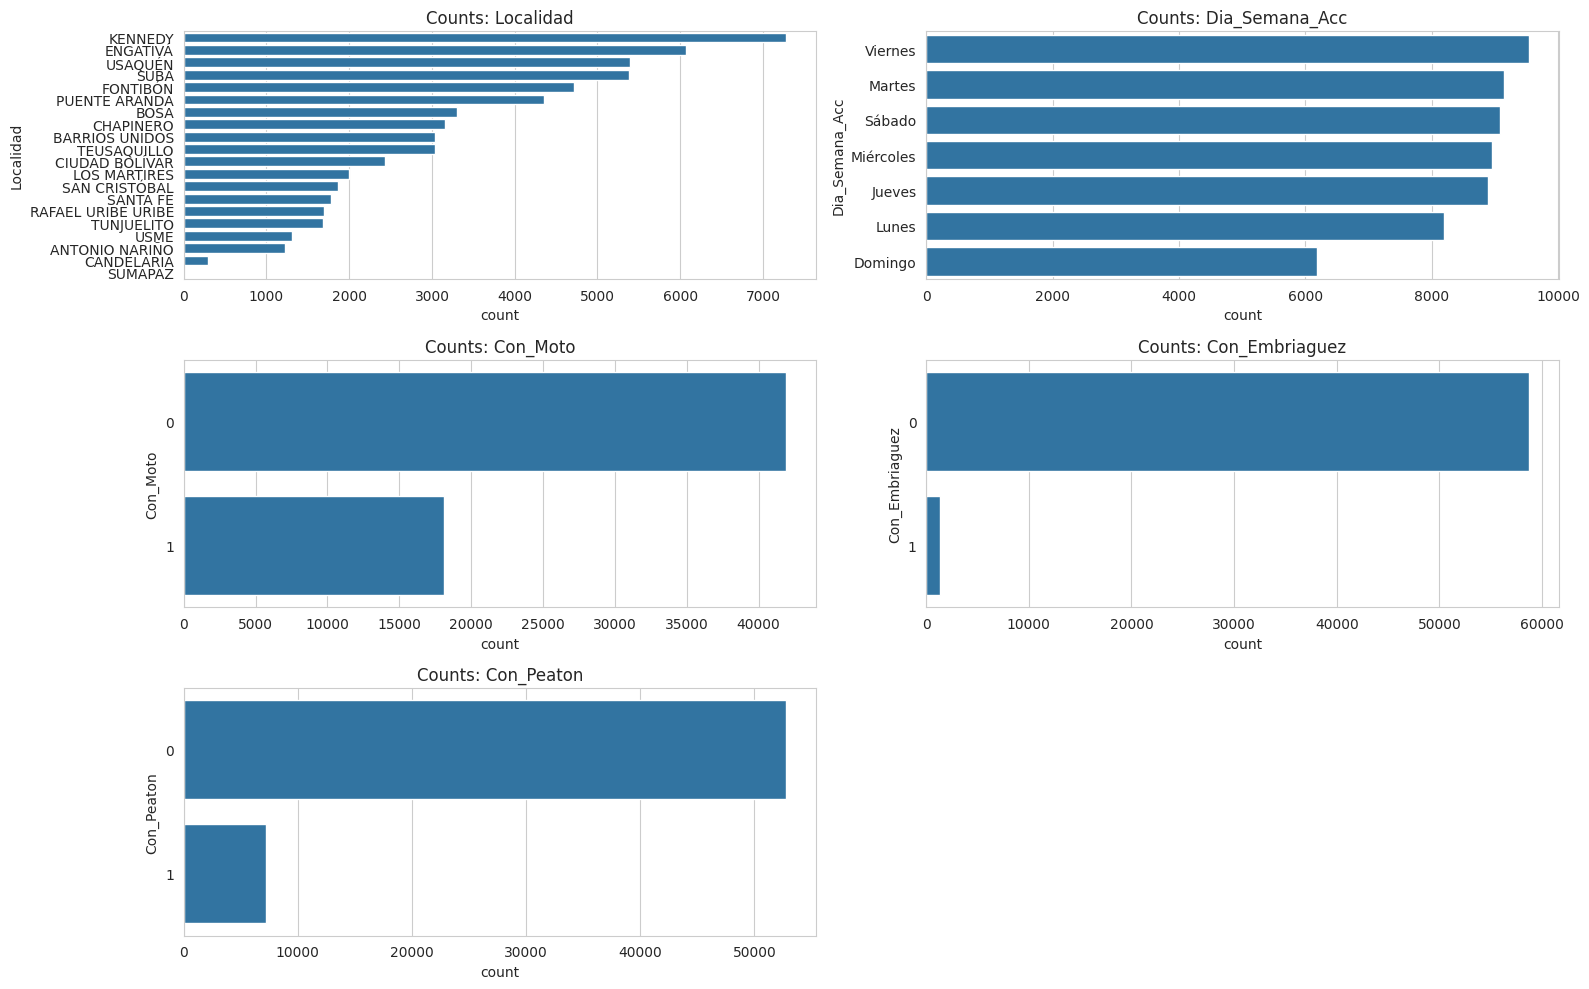

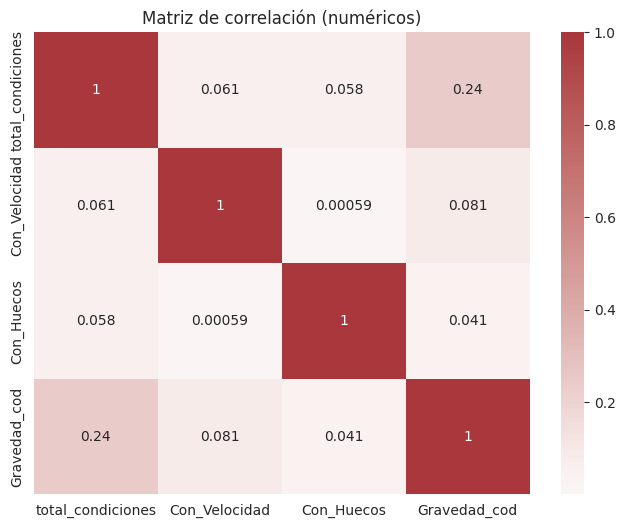

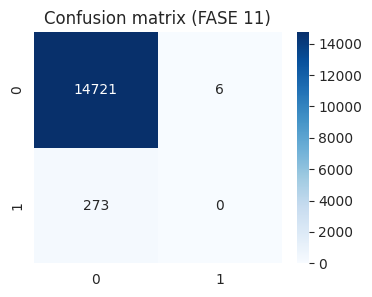

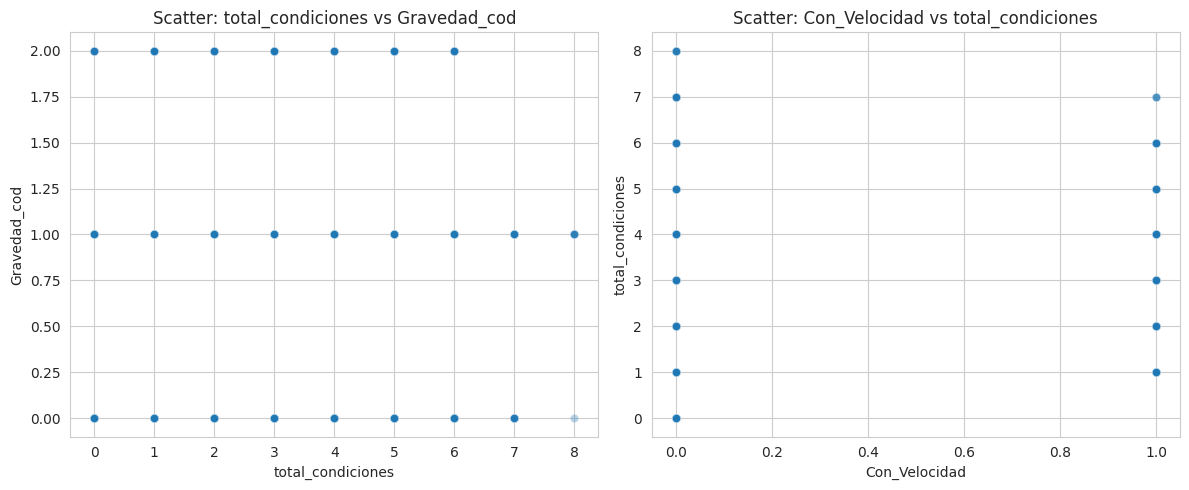

,total_condiciones,Con_Velocidad,Con_Huecos,Gravedad_cod
total_condiciones,1.000000,0.061021,0.058134,0.241474
Con_Velocidad,0.061021,1.000000,0.000593,0.080602
Con_Huecos,0.058134,0.000593,1.000000,0.041371
Gravedad_cod,0.241474,0.080602,0.041371,1.000000



Visualizaciones generadas.


In [ ]:
# Visualizaciones obligatorias: hist, boxplot, bar, heatmap, scatter, correlación, matriz de confusión
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_style('whitegrid')

# Selección de columnas disponibles
num_cols = [c for c in ['total_condiciones','Con_Velocidad','Con_Huecos','Gravedad_cod'] if c in df_encoded.columns]
cat_cols = [c for c in ['Localidad','Dia_Semana_Acc','Con_Moto','Con_Embriaguez','Con_Peaton'] if c in df_encoded.columns]

# 5 histogramas (usar available numerics, rellenar con repeats si <5)
hist_cols = (num_cols + num_cols)[:5]
plt.figure(figsize=(15,8))
for i,c in enumerate(hist_cols,1):
    plt.subplot(2,3,i)
    sns.histplot(df_encoded[c].dropna(), kde=False, bins=30)
    plt.title(f'Histograma: {c}')
plt.tight_layout()
plt.show()

# 5 boxplots
box_cols = cat_cols[:5]
plt.figure(figsize=(16,10))
for i,c in enumerate(box_cols,1):
    plt.subplot(3,2,i)
    sns.boxplot(x=df_encoded[c].astype(str), y=df_encoded['Gravedad_cod'], order=None)
    plt.xticks(rotation=45)
    plt.title(f'Boxplot Gravedad by {c}')
plt.tight_layout()
plt.show()

# 5 bar charts (counts)
bar_cols = cat_cols[:5]
plt.figure(figsize=(16,10))
for i,c in enumerate(bar_cols,1):
    plt.subplot(3,2,i)
    sns.countplot(y=df_encoded[c].astype(str), order=df_encoded[c].value_counts().index)
    plt.title(f'Counts: {c}')
plt.tight_layout()
plt.show()

# 2 heatmaps: correlation matrix (numeric) and confusion matrix (from last logistic prediction if available)
if len(num_cols) >= 2:
    plt.figure(figsize=(8,6))
    corr = df_encoded[num_cols].corr()
    sns.heatmap(corr, annot=True, cmap='vlag', center=0)
    plt.title('Matriz de correlación (numéricos)')
    plt.show()

# Second heatmap: confusion matrix if logistic predictions exist
if 'is_grave' in globals() or 'df_log' in globals():
    try:
        # use y_test, y_pred from last cell if present
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(4,3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title('Confusion matrix (FASE 11)')
        plt.show()
    except Exception:
        print('No hay predicciones disponibles para matriz de confusión adicional.')

# 2 scatterplots
sp_pairs = []
if 'total_condiciones' in df_encoded.columns and 'Gravedad_cod' in df_encoded.columns:
    sp_pairs.append(('total_condiciones','Gravedad_cod'))
if 'Con_Velocidad' in df_encoded.columns and 'total_condiciones' in df_encoded.columns:
    sp_pairs.append(('Con_Velocidad','total_condiciones'))

plt.figure(figsize=(12,5))
for i,(x,y) in enumerate(sp_pairs[:2],1):
    plt.subplot(1,2,i)
    sns.scatterplot(x=df_encoded[x], y=df_encoded[y], alpha=0.3)
    plt.title(f'Scatter: {x} vs {y}')
plt.tight_layout()
plt.show()

# Matriz de correlación (ya mostrada), y repetir como tabla
if len(num_cols)>0:
    display(df_encoded[num_cols].corr())

print('\nVisualizaciones generadas.')
